# Lesson 178 · A fair comparison needs comparable evidence

Reconstruct all 30 published runs and all 12,679 raw task labels. Implement three live contracts; use them to justify the stopped fresh experiment. Default execution uses NumPy, pandas and pyarrow only; no network, GPU, model fit or paid job. Ask the teacher for help at any step.

In [ ]:
from pathlib import Path
import json, math
import numpy as np
import pandas as pd
print("Complete saved-evidence replay; fresh comparison stopped; cloud/API $0")

**Your win:** decide whether three model scores are comparable before choosing a winner. Allow 15 minutes here, then complete the notebook's three live audit functions.

[Lesson 176](https://avistian.github.io/relational/lessons/0176-few-shot-icl-evaluation.html) showed that more context can change accuracy. [Lesson 177](https://avistian.github.io/relational/lessons/0177-compute-budget-realism.html) counted the work needed to obtain that evidence. We now combine those questions: **did the methods solve the same prediction problem with the same information and a defensible budget?** That is the comparison your [research mission](https://avistian.github.io/relational/MISSION.md) needs.

**Prerequisites:** full `(entity, cutoff)` query keys; training versus validation versus test; frozen weights versus label access; reservations versus measured costs. Recall [RelGNN's composite routes](https://avistian.github.io/relational/lessons/0141-composite-message-passing.html) and [RDB-PFN's relational prior](https://avistian.github.io/relational/lessons/0166-rdb-pfn-synthetic-relational-priors.html). The links in the notebook include the exact source implementations.

Recall how validation selection differs from test reporting, and why equal support counts may hide extra labels.

## 1 · Three routes; one prediction contract

A relational foundation model can reuse pretrained weights while conditioning on support examples. A supervised GNN learns task-specific parameters from labeled queries and relational neighborhoods. RDBLearn builds relational features and delegates prediction to an existing tabular model. **RDBLearn also uses a foundation model**: these are pipeline choices, not three mutually exclusive kinds of intelligence. [RDBLearn §3](https://arxiv.org/html/2602.18495v1#S3), [RelGNN §4](https://arxiv.org/html/2502.06784v2#S4), [RDB-PFN v5](https://arxiv.org/html/2603.03805v5).

<figure tabindex="0">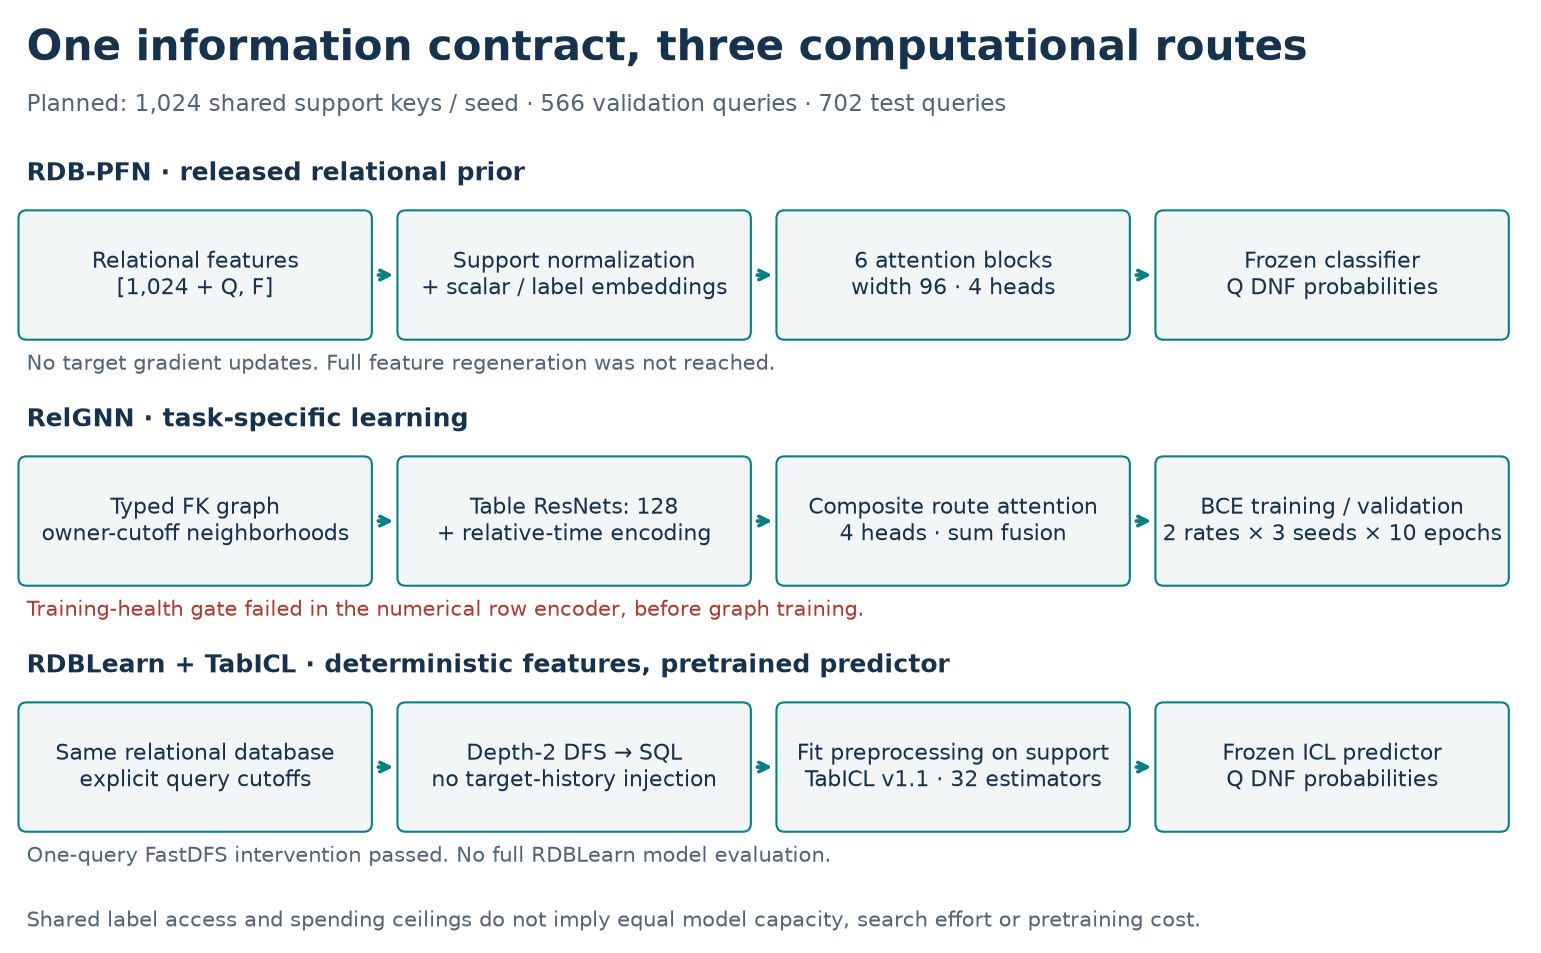<figcaption>Three planned pipelines with their actual internal operations. Q denotes the evaluation-query count; F denotes input feature count. All full fresh model runs are NOT_RUN. Scroll horizontally on a narrow screen.</figcaption></figure>

Our frozen course comparison planned RDB-PFN, freshly trained RelGNN and actual RDBLearn+TabICL on **the same 1,024 training keys for each of three seeds**. All 566 validation and 702 test queries remain. RelGNN gets two learning rates and ten complete epochs per fit; its configuration is selected by validation, never test. Each arm has the same $1.50 spending ceiling; shared preparation and validation also count toward the $10 aggregate cap. Equal ceilings do not imply equal search or equal pretraining investment.

## 2 · A shared task name is not enough

For `driver-dnf`, reconstruct the target from raw races: did any result in **(cutoff, cutoff + 30 days]** have `statusId != 1`? Check the entire `(driverId, cutoff)` population. A different cutoff for the same driver is another prediction.

Here the released RDB-PFN labels are **one minus** this raw DNF indicator for every one of the 12,679 train/validation/test rows. For saved predictions, DNF probability is therefore `1 − released_probability`. Complement **both** labels and scores; the AUROC is preserved. Use float64 subtraction when auditing saved float32 scores to avoid introducing new ties.

**Worked example:** a released label of 0 and probability 0.2 become DNF label 1 and probability 0.8. Changing only the column heading would call a 20% finishing probability a 20% DNF probability.

Do not infer the label window from a conservative support-availability bound. A 60-day window changes **82 of the 702 test labels**. The original 30-day source definition and raw audit are linked in the [protocol](https://avistian.github.io/relational/labs/l178-reproduction.md). The cohort also requires future participation; this is not an all-driver prospective forecast.

Predict: must you complement the labels, probabilities, or both to preserve AUROC under a change of positive class?

Equal support counts are another trap. In the pinned RDBLearn implementation, optional target-history augmentation stores the full `X, y` **before** downsampling. Passing 11,411 labels and setting a support cap of 1,024 could therefore expose more labels through relational features. Our proposed matched arm disables augmentation and passes only the approved support. This concerns explicit task-label access; shared historical database facts remain available. [Pinned estimator](https://github.com/HKUSHXLab/rdblearn/blob/b5b03ebf8091547285a6e06cba53d2d1a40cb171/rdblearn/estimator.py).

## 3 · A valid comparison needs a model that can train

**Recall the two passes.** The forward pass computes a prediction. The backward pass computes gradients: derivatives that tell the optimizer how changing a weight changes the loss. A finite number is neither infinity nor NaN (“not a number”). A finite prediction can coexist with a NaN gradient, so prediction checks alone cannot certify that training works.

**Observed:** published-result replay **COMPLETE**; fresh three-model comparison **INCOMPLETE_TRAINING_HEALTH_GATE**. The local encoder probe has **256 nonfinite gradient entries**. No fresh benchmark model fits or inference and **$0 cloud/API spend**. Whole-paper reproduction and repaired-model training: **NOT_RUN**.

The actual FastDFS preflight produced 65 columns for one real support query. Changing numeric non-key cells at or after its cutoff left those outputs unchanged. This diagnostic passes; it does not prove every feature for every query is temporally valid.

The next check failed. The released RelGNN row encoder received 58 earlier results for driver 34 at the 1999-08-01 cutoff. Among eight numeric columns, `milliseconds` has 30 missing values and `position` has 21. Its output is finite, but **256 numerical weight-gradient entries are nonfinite**.

<figure tabindex="0">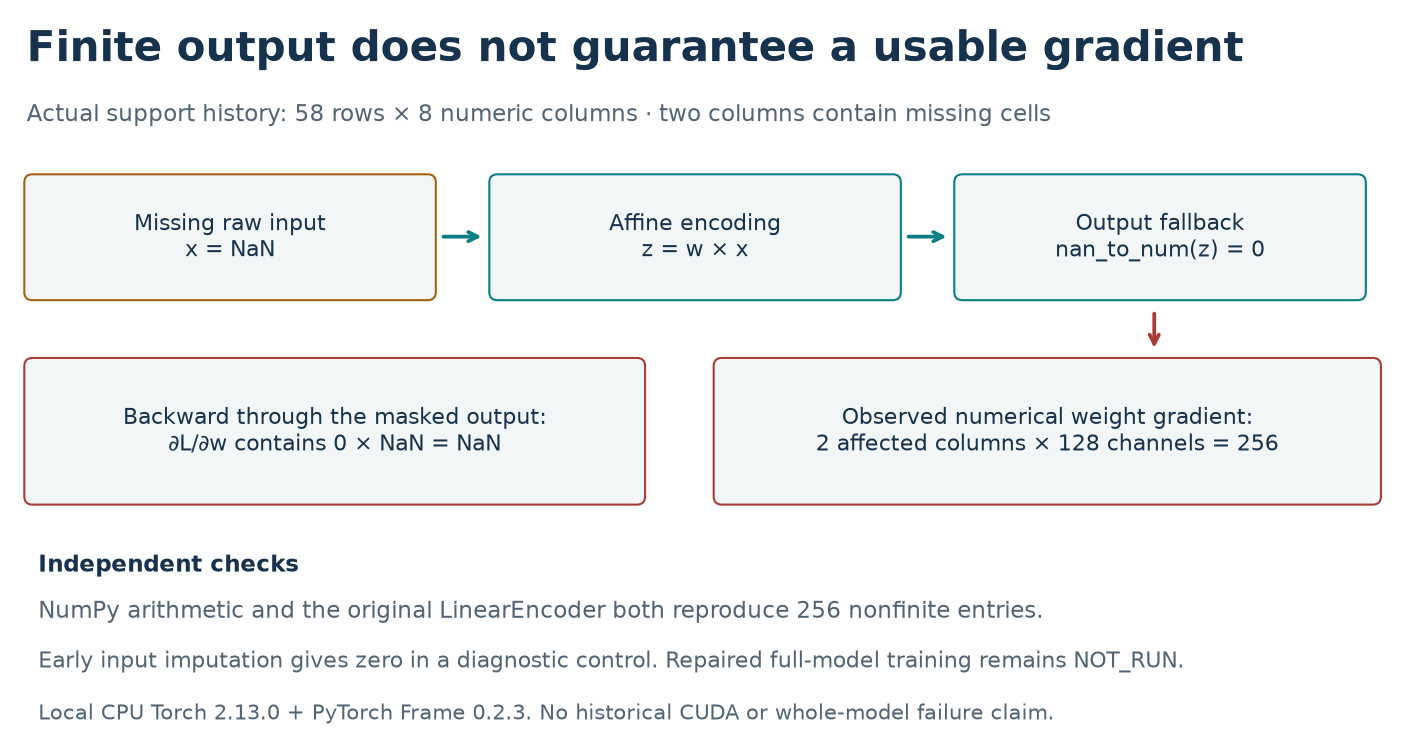<figcaption>Actual raw support-history missingness triggers a local numerical-encoder gradient failure. The diagnostic repair is not a new benchmark result. Scroll horizontally on a narrow screen.</figcaption></figure>

A scalar trace explains why. Let a missing value be `x = NaN` and compute `z = w × x`. Replacing the resulting `z` with zero makes the forward output finite. In the backward calculation, the masked branch contributes `0 × NaN` to the weight gradient, which is still NaN. The source applies its fallback after the affine operation. The independent check reproduces the failure using both arithmetic and the original numerical encoder.

Imputing before that operation gives finite gradients in a **diagnostic control**. It does not prove that a repaired full GNN trains well or preserves the published behavior. We keep the approved stop: no six-fit tuning grid, no fresh ICL model evaluations, no invented winner. The local probe uses CPU Torch 2.13.0 and pinned PyTorch Frame 0.2.3; the historical CUDA runtime was not run. [Original encoder](https://avistian.github.io/relational/labs/sources/l178/relgnn/examples__relgnn_nn.py), [actual probe](https://avistian.github.io/relational/labs/_gradient_preflight_l178.py), [independent check](https://avistian.github.io/relational/labs/evidence/l178/gradient-independent.json).

## 4 · What the completed replay establishes

| Saved published arm | Replayed mean AUROC | Sample SD, 10 supports | Paper reference |
|---|---:|---:|---:|
| RDBPFN | 0.721938 | 0.019983 | 0.7219 |
| RDBPFN_single | 0.663990 | 0.034177 | 0.6640 |
| TabICLv1.1 | 0.717568 | 0.009770 | 0.7176 |


This is the complete selected **RDB-PFN Table 9** experiment replay: 30 saved runs, 21,060 predictions, all 702 queries, 512 support rows and ten seeds. Its three arms are **not** the planned RDB-PFN/RelGNN/RDBLearn comparison. In particular, the old DFS+TabICL arm is not an execution of RDBLearn. Sample SD describes variation over support draws on this fixed task, not uncertainty over databases. [Primary reading: RDB-PFN v5 Table 9](https://arxiv.org/html/2603.03805v5), [full audit](https://avistian.github.io/relational/labs/evidence/l178/report.json).

<figure tabindex="0">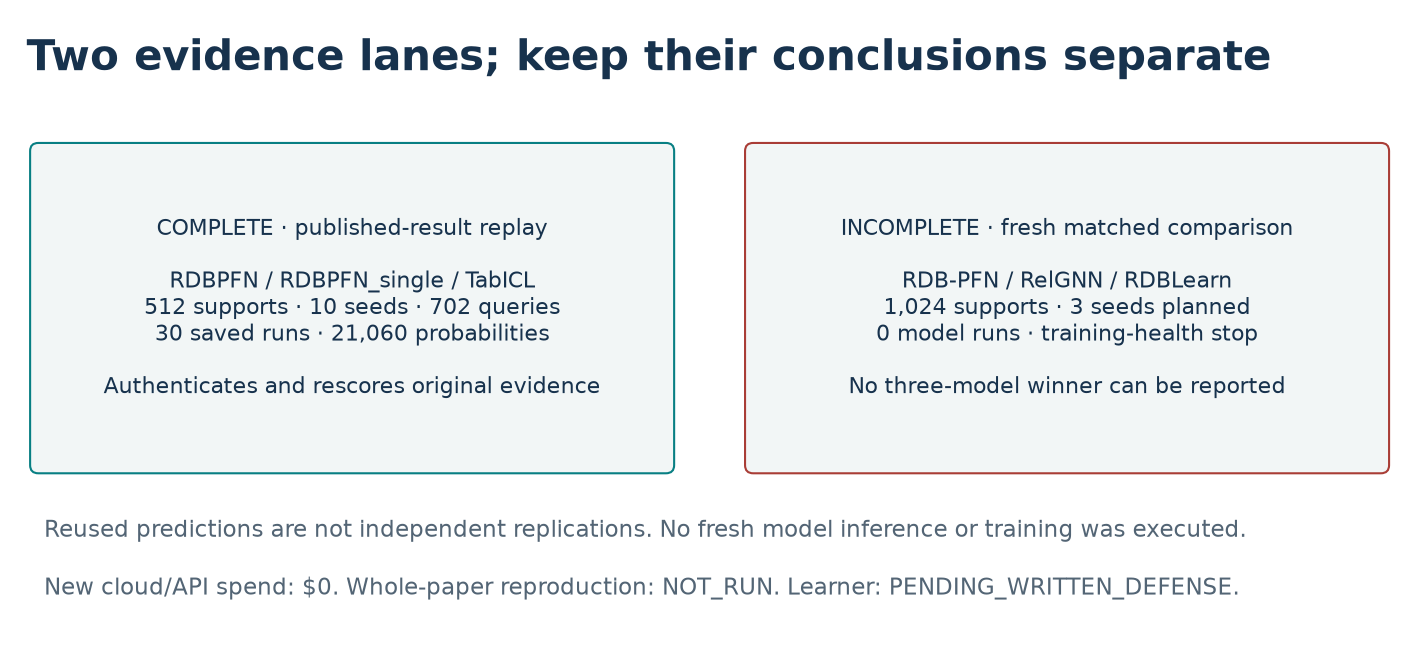<figcaption>The complete published prediction replay and the stopped fresh comparison support different claims. Scroll horizontally on a narrow screen.</figcaption></figure>

A complete replay can coexist with an incomplete fresh comparison. Preserve both facts. Reusing the same predictions in another lesson is not an independent replication.

## 5 · Try to admit a comparison

Use your live comparison_gate function below to vary one contract assumption. A hypothetical pass never alters the real stopped evidence.

This explorer is a **hypothetical contract exercise**. It never changes the observed failure or launches a run. First match the label horizon, explicit label access and validation selection. Then vary training health and whether the complete audits have passed. Even READY_FOR_PILOT only permits a budgeted diagnostic; it does not establish a completed comparison.

Implement the comparison gate in the live TODO below.

**Notebook task:** implement (1) full-key AUROC, (2) the information-and-health gate, and (3) validation-only selection over a complete tuning grid. Your functions rescore all original predictions, determine the real stopped status, and reject selection from the empty actual tuning grid. Then use a labeled practice fixture to show why a tempting test score must not choose a configuration.

[Open student notebook](https://avistian.github.io/relational/labs/0178-fair-model-comparison.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/0178-fair-model-comparison.html) · [Quick reference](https://avistian.github.io/relational/reference/fair-model-comparison.html) · [Reproduction contract](https://avistian.github.io/relational/labs/l178-reproduction.md).

## Exit · Defend the missing leaderboard

Without looking back, explain why identical task names, equal support counts and finite predictions each fail to establish comparability. State exactly which reproduction is complete and why the new three-arm result remains incomplete. Propose the next **newly frozen** experiment: an explicit encoder repair, full feature/temporal checks, pinned-runtime validation, the unchanged complete tuning grid and a new all-attempt budget.

Write the defense at the end of the notebook and ask the teacher for feedback.

Ask the teacher follow-up questions about any unclear step, especially the label complement or `0 × NaN` trace. Author verification does not establish your mastery: the written defense remains **PENDING_WRITTEN_DEFENSE**. **Lesson 179 · Failure modes is planned but not yet available.** Continue to [Lesson 180 · Public encoder checkpoint](https://avistian.github.io/relational/lessons/0180-public-encoder-checkpoint.html), which recalls the necessary failures from lessons 175 and 178; it does not require an unavailable lesson.


## PROVIDED · Authenticate every original input
The packet includes every prediction NPZ and original receipt, complete raw task/database files, model sources and the actual preflight evidence. SHA256 checks byte identity; it cannot prove historical information availability.

In [ ]:
import base64,hashlib,io,zipfile
PACKET='...'
raw=base64.b64decode(PACKET)
assert hashlib.sha256(raw).hexdigest()=='93169a431016e3a7af74d8868d669bac7e944f586ea545bece8a54ce5a4b5f56'
P=Path('l178-packet');P.mkdir(exist_ok=True)
with zipfile.ZipFile(io.BytesIO(raw)) as z:
    for name in z.namelist():assert not Path(name).is_absolute() and '..' not in Path(name).parts
    z.extractall(P)
pins={'experiment': 'L178 Matched-Information F1 Comparison', 'files': {'_gradient_preflight_l178.py': '510fa4ad617d86979688050be5fd375d06e6975f84a0fa75ef6fcc0e94488094', '_parity_l141.py': '568ec49a993acbc7bff786f7041cd9c39ca1fad70c5bebfc30a15586c6b5899f', '_preflight_l178.py': 'a104ee49bb9db382e8e6f96e2443faee97ece3a8e3419610315917082a557a96', '_report_l166.py': '5291c38db45ba7a32c92fae93c9be88a0a161fbffa119398cb37ccf5dba060b7', '_verify_gradient_l178.py': '87eaefe11da84af09d3abcbdb25cad904c160acb70d12e889c7cfb9f608ad60c', 'evidence/l166/full-1/RDBPFN-1.npz': 'b234f020b1076ea01e1f38dc048e7f3be8aea6dcba21da845d8ca0fca72a7fae', 'evidence/l166/full-1/RDBPFN-2.npz': '874bf69e6c96d57e8a93936cd2d2e46c778ded54ae93edd4b8a62516ae62398f', 'evidence/l166/full-1/RDBPFN-3.npz': '3f01dd8ca7ffeb66f98aea347ef2592f23e1ba70df6f832a97825ae06b113a4b', 'evidence/l166/full-1/RDBPFN-4.npz': 'ae2ddcbdf66ebac5a196349f54a1f4d34c9df98e8660c97e70829606ab4a8dc9', 'evidence/l166/full-1/RDBPFN-5.npz': '02803816d249ca1f275dfed37870f90992aafcd1d30bc53d3a62f64a6456f93f', 'evidence/l166/full-1/RDBPFN-6.npz': 'aae3b3c774b9cc1364770f2037eba3cbf4a7ed7cd6e543432175e92d8ed3bbd2', 'evidence/l166/full-1/RDBPFN-7.npz': '0e74602505fee5446e8da5d2532dc568f1616fbc6af1608e1c70706e36fdc839', 'evidence/l166/full-1/RDBPFN-8.npz': 'd9c3d8b5c2f847d040e7302b607a5e3cec0da79c0e1e4634b5ee75b73592eee6', 'evidence/l166/full-1/RDBPFN-9.npz': 'df98ef5462c41dbdc064760b35caf8ca3819dc9fc6836880410310e4d62aedb2', 'evidence/l166/full-1/RDBPFN_single-1.npz': 'a5d87cde2d885b55a92e1bd248fb562e55a5e1acd9e8ce2c08c86500bf693b50', 'evidence/l166/full-1/RDBPFN_single-2.npz': '1ad0c3c73462f95d4bfb12e6bccdc8c1ed1fe8f219411e84926e0c13d39bc8a7', 'evidence/l166/full-1/RDBPFN_single-3.npz': '72f566d2e5270b35fae3ab9ccc8c60d7f95f06530fa164dc74f77159e5cbec78', 'evidence/l166/full-1/RDBPFN_single-4.npz': 'ee3f8128682b2e9ff168fd14ad11cd629274463f1d30ca65e9a0d5c87b89e69e', 'evidence/l166/full-1/RDBPFN_single-5.npz': 'bf966a1143912259be2aff2f8d1e1460992039363c347960234f204c58e14075', 'evidence/l166/full-1/RDBPFN_single-6.npz': 'bbd130e58fbd44eec1783a78019adccb15bd6eace254af5f32ee0aaae8ecf989', 'evidence/l166/full-1/RDBPFN_single-7.npz': '02a158e9d726f4553f9e8c76d17810ccf1d2e8c5c4e9de964a0ca7b64b9e2389', 'evidence/l166/full-1/RDBPFN_single-8.npz': '85bb14ba7154e7aa90e794f9a49e478b1d35e6e064031964d3715e215b72b18b', 'evidence/l166/full-1/RDBPFN_single-9.npz': '693cf63d27383e8e603de6ae4f30f993cf4e5bf19afb46972d3c169c03bc6659', 'evidence/l166/full-1/TabICLv1.1-1.npz': 'd25c341b6145eed5380866e54ae6f4753d798f9d461125dce1ad41ef1a6efa14', 'evidence/l166/full-1/TabICLv1.1-2.npz': '8b9f2f0b0f9dcacea0ae95923e56fd961e3ffbbc361c4b6ed8535a954b971bfe', 'evidence/l166/full-1/TabICLv1.1-3.npz': '85c55bb62822daa0e305b552f3a0a6ce9149feec8a80c5f8762a92ac6a0b1f44', 'evidence/l166/full-1/TabICLv1.1-4.npz': '8d8f2e3eaa791be21f31f939e2011bfe016269e35b8a3371473dcda9454e7022', 'evidence/l166/full-1/TabICLv1.1-5.npz': '3000d3e27cd2288ad33b9161f8bb313d6ce34a5b9bd21f5f3050e6b2d1937083', 'evidence/l166/full-1/TabICLv1.1-6.npz': '91eb8ebecd2c4b71cb6bf40c1f001f44e403d8005b4e612675b9cc59309de69f', 'evidence/l166/full-1/TabICLv1.1-7.npz': '353f764d50857e8386ac204aca05d34d044f07832f9ff95e5cbe7784a3be0ead', 'evidence/l166/full-1/TabICLv1.1-8.npz': 'e2269ccfca7cd52c45334786489856103e544b9b244363452ee64b26f4cb7226', 'evidence/l166/full-1/TabICLv1.1-9.npz': '1025f3d8eff81dea26b142a78c33af9ff95a0b02d8d477804ffb1f52233218e9', 'evidence/l166/full-1/receipt.json': 'c80106b3673acb3e6f690292f13eb98d6a606119ac7392a6bfc9c8023f5cc35b', 'evidence/l166/input-manifest.json': '76d0c10a4f083136dfac5254e57788770381887443b722e47ff9484998206b1f', 'evidence/l166/pilot-2/RDBPFN-0.npz': 'efaaa6982c5c5782e22d35ec4cc9fc82adb33703d8d6ac1206b987b81e4ed9e6', 'evidence/l166/pilot-2/RDBPFN_single-0.npz': 'ec98be9f74006395e5f5cf5a54087dc54cc661eb8f956200781f4c2fa470bfe8', 'evidence/l166/pilot-2/TabICLv1.1-0.npz': 'eff980b9aef9eff48c388721fd2da896f2847390d65605e028b24b334099e681', 'evidence/l166/pilot-2/receipt.json': '52efe0d8c66f00859a1c99e65e1806f4d334d23e9d5bf3e31ce731a1bcc4de1f', 'evidence/l166/prepared.npz': '9f4a0e9245420127c6391196bdc1a33dba4bbb88bdf3e42161912e3763a20bbe', 'evidence/l166/report.json': 'e258c9ff926c4f0a6d731438ad0c486da8df21883ade2650900e66044a8df6ad', 'evidence/l171/db/circuits.parquet': 'c36c6537b9c5c9985ec438110717e93289085a5bffbcee07d08bbe1771994d8d', 'evidence/l171/db/constructor_results.parquet': '35582c2f0634d5503b664babf38264311332e6ca3cb612fb0fe737bfaffdc29e', 'evidence/l171/db/constructor_standings.parquet': '739fc21ba301ef2081dbd8e56d643f148b672224a4d223b95d6107ccd735aa6b', 'evidence/l171/db/constructors.parquet': 'fc79dd346430186cdca6263e1c532891bf4d4ba7463fd94b398350a9356180c6', 'evidence/l171/db/drivers.parquet': 'ba3461b83a1a467a856bde4059519140a5a31952ad24a5e944ea9dd5c5faceae', 'evidence/l171/db/qualifying.parquet': '2d5cb7b4ed6cf4076b74ab1cc79f5f35faf31b7f032b51d2a1ac814e1d0c834b', 'evidence/l171/db/races.parquet': '88bb260f03c9ec5c7b030969d7284531d5f8e8592d73174686ad01cdfc8f87ea', 'evidence/l171/db/results.parquet': 'b8b0e39b27f318a7bd461f21bb0ba9ef44909ed569d287e0c6b2969c6bd2f598', 'evidence/l171/db/standings.parquet': 'f3f6a34fee190f077f2fe48026a7e5659e4c91a34f72340cdff3cf407c1f3534', 'evidence/l178/config.json': '5c45ab48e15946c842d6bc79ae07cf7966ef690aa37f5344f5494def7199c83d', 'evidence/l178/fastdfs-preflight.json': 'f45032efd14ef33a214172dfe2fcb3a89873153013062523b3b9d4f5173f2cf4', 'evidence/l178/gradient-independent.json': '12bf567dc743d8f94e789a44e58e864a591f275d9772738accfe15f97b9ef1ec', 'evidence/l178/gradient-input.parquet': 'ad71612a8338a6bbd3867f2b55c8fd2e06168788abfdf661a348fae785689295', 'evidence/l178/gradient-preflight.json': '4cca6e20a92b8f512f2dcc966a7392f778dc3643bca8b0c0ee5b9ba6fba31357', 'evidence/l178/input-manifest.json': '19ef3167985cb36c6647dc1334da15137469403b08b38489040e5470ad8423a5', 'evidence/l178/preflight-baseline.parquet': '27617918a17ed2b3ca5cae2b175600019ce5ee5dd24990b014fbbddf8fa19ba3', 'evidence/l178/preflight-mutated.parquet': '27617918a17ed2b3ca5cae2b175600019ce5ee5dd24990b014fbbddf8fa19ba3', 'evidence/l178/released-task/metadata.yaml': 'e4df99d3cfbdcc437fc7459e0cf62f5779f05e1ec83d0c61ede0d2f7497873ed', 'evidence/l178/released-task/test.npz': 'f69accc988937461d2bea05641bb1775c78dcb10ece0efd8e7d1ab5ea3d76750', 'evidence/l178/released-task/train.npz': '6fe08c95847eb67cecc86e3db91f3c6b2a694fdbd8717eaecbd658eabae815d2', 'evidence/l178/released-task/validation.npz': 'abc060d3a545bf2b80264d134141872a5a6fb24d3d05a3ce8db93cf99c464961', 'evidence/l178/support-schedule.npz': '9684805f00bd21600536fddd3593d02a0e90ab9561843090109439dca209db0c', 'relkit/relgnn_l141.py': '7c7f3662fd475af1916b0800143b5fe9eac5674b50401c3f11a2fdf70d0ca897', 'sources/l166/input-downloads.json': 'ad70a7aedfb669bc6d936e66c4d34cb3bc0ac48bf19234a6f71dfd533dd2dd69', 'sources/l166/upstream/data_preprocessing/configs/dfs/dfs-2-sql.yaml': '8a27a292d376ab96983721f095c9f639c76f9ef21c3d20522dff0a587e8a4f0a', 'sources/l175/relbench-f1-task.py': 'a9cb6ec5f07c21cb7966c8bb9743d9cbb18c16c9c969e4c8ca629897c7de335c', 'sources/l178/fastdfs/__init__.py': 'aaf9249ef14b27af76539bcb938c9f4c039412241a1e430adb9fd118cfdee1b5', 'sources/l178/fastdfs/adapter/__init__.py': 'eeb30bd923b08d4c0a695ebe773dd95fdeb48ee9b57f38a8374cd7832e45624d', 'sources/l178/fastdfs/adapter/dbinfer.py': '117d6d8f861b2b4d48607d413e51c09f307396576ccbf6f463229dd6aaf8cda4', 'sources/l178/fastdfs/adapter/dbinfer_bench/__init__.py': '87f4e1286fc442d5cb409bd2b8e7593e43c26b5cab6b08723ce97d3e4201ddf2', 'sources/l178/fastdfs/adapter/dbinfer_bench/dataset_meta.py': 'ab6156cb23c2c81d5b672f45d6616eeffa9cc9549f315ce2681a545d3b55f786', 'sources/l178/fastdfs/adapter/dbinfer_bench/download.py': 'f972db5b652ddd4dbea536d27ae3fa47945157bf3a72f16fa74a4099efc1d1a2', 'sources/l178/fastdfs/adapter/dbinfer_bench/rdb_dataset.py': 'c02812ca04d548954c6d61312efa07b59cc20399bc35966b834829ccf117397b', 'sources/l178/fastdfs/adapter/dbinfer_bench/table_loader.py': '2a8faa978c6fec487859e4409e777975b5ef9a6825c787f44d3223ce87499f3b', 'sources/l178/fastdfs/adapter/dbinfer_bench/table_writer.py': '50b7a81666d2534fec91ae3e8e88c91c64a1c8ce1f312b6eb9fd3f84bf435910', 'sources/l178/fastdfs/adapter/dbinfer_bench/version.py': 'd4bd2737bbae7d8661c1aa896ae5926173ff99efeecb15bfd12c6ec96438c301', 'sources/l178/fastdfs/adapter/dbinfer_bench/yaml_utils.py': '502cb8be0da0fa8b80ad8108ffd00096f8729d0f2b301ea83d1c054e951d4532', 'sources/l178/fastdfs/adapter/duckdb.py': '940c4d5e1d279b8b5727166f4ad023fc0e2629f8e53438d511099403804c5fd2', 'sources/l178/fastdfs/adapter/mysql.py': '91b24cabf8767ca8db181ce7da9bc98b3eb54a08ceca4c450d5843b4b3644908', 'sources/l178/fastdfs/adapter/postgres.py': '40f74d069ea2f45767123ed684ed74bab0c704da2740de8f333c2b12a4b81f19', 'sources/l178/fastdfs/adapter/relbench.py': '3bf94a756c095d4abda4d2ec6090c0da07170e3da021d984676c2f919d18d420', 'sources/l178/fastdfs/adapter/sql_base.py': 'dd4c0be0a4b5cf80e485142f5d3dc2c9b380518170012c1a603b92f4458b0ac5', 'sources/l178/fastdfs/adapter/sqlite.py': '05f58a8add678ad57edc9671cc06a25aa25ad68006b490750988ec65c2bcd561', 'sources/l178/fastdfs/api.py': 'f7187d6b05377eb1337b5a2da7a33c16d4cf4f00c376ba7af8f2b8c9389bdfc5', 'sources/l178/fastdfs/dataset/__init__.py': 'bee808cad46eaae7b1ac0595eb198fc8b3c50d2c5eed1501834e70add3dfaa71', 'sources/l178/fastdfs/dataset/loader.py': 'b633dc5c70706b3e520655a6b027621ef40661875e848dfcd4d7aa6fceecf792', 'sources/l178/fastdfs/dataset/meta.py': '9446032cad79afad7bf21fac0d914c47e4cfa4cffdd40181f86be196eda9146c', 'sources/l178/fastdfs/dataset/rdb.py': '50fb2f6d1ba413854a0becc013433d5f60b44f441c885b380fa698779b28e942', 'sources/l178/fastdfs/dataset/writer.py': 'bf4fc1bb81d5404dec7bc85473bb39a37801f16960802ce9015f9614fd355625', 'sources/l178/fastdfs/dfs/__init__.py': '34a2eeef47f1fcf3d98ecc2356b46598231dcbce08f74cbc5f3fcc79cb72888c', 'sources/l178/fastdfs/dfs/base_engine.py': 'f74b5535addb69eea9affc3331904bb034140b570f0f105d4f4898c44892b3d7', 'sources/l178/fastdfs/dfs/dfs2sql_engine.py': 'a3832be0fcfca682b8bc12d15f9c4f64e58671d9702c7de630fedc46323f18c6', 'sources/l178/fastdfs/dfs/duckdb_database.py': '1477f4d3521604a64fc97c3dbb78fa074aa5f3816e36bfaa0f0403bd2c73b4c0', 'sources/l178/fastdfs/dfs/featuretools_engine.py': 'a97cda13dfeca0cb67e6aca95d487e81e43d864336d6869e07303f6a544216e3', 'sources/l178/fastdfs/dfs/gen_sqls.py': '1ea2ff6c56ceadcf81f1b1ff0c97cd357bf6892659f18a1f5337b0b0fefa481b', 'sources/l178/fastdfs/transform/__init__.py': 'fe31b56a3bbe28171565b21fd32ea90de0eee9cf55034bb10d3129d7e425f862', 'sources/l178/fastdfs/transform/base.py': 'a572029c1e61c7e01049ec7e06119b256236ecea9a7377e5f2c92c247acf807d', 'sources/l178/fastdfs/transform/datetime_transform.py': 'e0828400f6a8e1a33c174d6b52a03dc96d32ffc0ac3ef1b4818b5a2f951948de', 'sources/l178/fastdfs/transform/dummy_table_transform.py': '2099d76d60c80aaf100f755fa10c1bea47522b4bd6fbd6cc7e9717dc6f6cc753', 'sources/l178/fastdfs/transform/fill_missing_pk.py': 'df4dbd1c5d2f946fb2a9f2caef9f032f8f943f3bd7f314992ec5938a957d30ad', 'sources/l178/fastdfs/transform/filter_transform.py': '467ef3850706dc6e24c32ae9954142ac81af93a734322b2e093647ad559eecdd', 'sources/l178/fastdfs/transform/infer_schema.py': 'dba98f8d33273e08b82ecca261be2e7197b3815bf6602e85aa9d7d886cd34dfa', 'sources/l178/fastdfs/transform/type_transform.py': '7aac6cdc05b8daf4101a121ab34526a415d6eddac89fefc193fb5aad7b832144', 'sources/l178/fastdfs/transform/utils.py': '36178a11ca25c523e197b58aac4147324a51856c582947c38d17f76655a035fd', 'sources/l178/fastdfs/utils/__init__.py': '2dccb171343f0f81d8b159a847df81c01617b49fb3ac989b1d6a851c96cc8641', 'sources/l178/fastdfs/utils/datetime_utils.py': '7d6b95199c989413a9a0b6d327b80e249ed0b41cac65413b00898c5464d93fa9', 'sources/l178/fastdfs/utils/device.py': 'eda34de5c5518cc34d6b087200beecae7c4413b618127f300b0685d760c2f2b7', 'sources/l178/fastdfs/utils/logging_config.py': '54b5017e026d36e6a3124567aa50d8ae078c811be28e42f6955b2177fafa8a17', 'sources/l178/fastdfs/utils/type_utils.py': 'bf0e2922e0f4b428e678f6085555c0f06a2f8314f72ac7f3dd3cf9b7f39c06ee', 'sources/l178/fastdfs/utils/yaml_utils.py': 'e817d0e5f64b2a463ee98c5b56f0146041e77bc39e698fae658d8eb7fda47e07', 'sources/l178/fastdfs-LICENSE': 'c70b1de2cdbb8b6e2db401038ff685c1d0133d78a0e4f065691bc8b477216a86', 'sources/l178/fastdfs-METADATA.txt': '8445893b361d09f1ddf18bfbf9a94567bbae38d3bcc93fa86f78675dc6e72d41', 'sources/l178/pricing.html': '35cf9f36fd3167236edd190ddf338383da75bf2eb12cd1d0549f0f546a632472', 'sources/l178/rdb-pfn-v5.html': 'b22e65e338a69e8b0fefa9acfcfee45063e0eb15b59ccee7c017ade29560f617', 'sources/l178/rdblearn/.github/workflows/ci.yaml.bak': 'cf85896fb237d2308ed29a8d0bba7ec516d013b82a0a3c71259ff93199467e82', 'sources/l178/rdblearn/.github/workflows/publish.yml': '02e9847e1e13d6717070055d33fb89e1840c85cb4859698d8f337b046f05d8e9', 'sources/l178/rdblearn/.gitignore': 'fcd4e0a801b65296e274163bff0fd5a1ac4d751e56214e84feadfbca22e244e8', 'sources/l178/rdblearn/README.md': '418db0129395e506b7101ea5f813bf214272c88fb6c1d81020e19052fdacf3b7', 'sources/l178/rdblearn/SKILLS_INSTALL.md': '9d4ce9c22ebcd04e18d2c20a58c5d70f231c501359f6027169b045f1b5bc75e8', 'sources/l178/rdblearn/examples/rdblearn_4dbinfer_example.py': 'c1f973ec49f6c0fe2093def7ca0556c82ec606dedc3a43646085d6b35dda0d97', 'sources/l178/rdblearn/examples/rdblearn_limix_example.py': '01bca239a711593915583806ac6755ba32d1e1625db5880063c0ad9117ec2583', 'sources/l178/rdblearn/examples/rdblearn_relbench_example.py': '4029e0ac7b677267235ff1091ef7e47ed0f41a71fcfad33c49753fd543103ff0', 'sources/l178/rdblearn/examples/rdblearn_relbench_reg_example.py': '62b44ed0b57220e6ffbd5826dedaf0d33b5c93d84a352b98015a97eda0ad75c5', 'sources/l178/rdblearn/pyproject.toml': 'eab049a9866b358a516993f66539f8c0db08c3b4e234cc388457d88c426ed2fe', 'sources/l178/rdblearn/rdblearn/__init__.py': 'c2bbb25e60b0bf5600f770c5036570f1613ef0e52d78586ee8c881e16b4cec5b', 'sources/l178/rdblearn/rdblearn/config.py': '3e964deae390ee1634732906350d0c1cce5f062e68a73e4693ad045132694f0f', 'sources/l178/rdblearn/rdblearn/constants.py': '26add045030ba0af141b0ecf2cc2b573402d3a64c2c1163f6c2e40b5498340fc', 'sources/l178/rdblearn/rdblearn/datasets.py': '7033a11d608242a9bd5d39989874e0a46f46c6179e618881d4c95b1c5c6b0fef', 'sources/l178/rdblearn/rdblearn/estimator.py': '44df25e6b43f3bfb86f5e2aa9ec23544aedf565c7e9e35706918365c4e71c23e', 'sources/l178/rdblearn/rdblearn/preprocessing.py': '87fa6f9fe7d441fbcd5fd4e6119fd97b35a13c6d2ad6dd3e4195beb9c3229371', 'sources/l178/rdblearn/rdblearn/utils.py': '3e01f2d8bcbd26125523b6b67233cd4628287bf5b388d1fd578a322d72ce0573', 'sources/l178/rdblearn/requirements-gpu.txt': '9c65380919b7a07f485226f3e9c9333c39207e4ba239662025af8788a2cda670', 'sources/l178/rdblearn/tests/test_preprocessing.py': '83578694bc56dcac87afefe9037ff19b2447061bfcf1831426ff7f2ff9e554db', 'sources/l178/rdblearn/tests/test_rdblearn_datasets.py': '33544c9b92cdebc8d4be1ddbcd55c991ad0a3774c26dac4a5dd1ccccc8bd5417', 'sources/l178/rdblearn/tests/test_rdblearn_estimator.py': '66085c279249b0d74ef545699e3409b8955c3682dcd29628dcaa0e01565a45b9', 'sources/l178/rdblearn/uv.lock': '4798371e330e8317e29789d14c3e4468c6d4b4810fc20bed737b8464dc496128', 'sources/l178/rdblearn-v1.html': '436e66c9ac1b494c5217a74d205a87240224d81b00b953b0273616a8f5ed882c', 'sources/l178/relgnn/LICENSE': '373b7c4e5ab541b3a753e1cff5643f494bbc2f6f6917d8fbd225de8ea7dbf3fc', 'sources/l178/relgnn/examples__atomic_routes.py': '5cabcdfe2ab9eb3916f1e10d8910e0242d144507dae6bd6c7835a53de08fe586', 'sources/l178/relgnn/examples__relgnn_conv.py': 'f7a013a362be077246a22192c1912e6234a8339e881a3193002b2dbe2b603f2e', 'sources/l178/relgnn/examples__relgnn_hetero_conv.py': '3e146340fd449c5210c93d3b13aa877f2d89f820aa3262633d0c2d18bfc84e81', 'sources/l178/relgnn/examples__relgnn_model.py': 'a18ac7c80dc3bcaf66d1e9d7d2edb08ab874c21288b103999fb5d79baa7b3f3b', 'sources/l178/relgnn/examples__relgnn_nn.py': '2cb20ccacbf18b0ca466cd0f816618097d6b21018438e05e54a649e5762d75e0', 'sources/l178/relgnn/examples__relgnn_task_node.py': '7da09c83a1f4ac3a57b2a5625f4a8ab726269b55cb3d0da5a467827198d55bc8', 'sources/l178/relgnn/examples__text_embedder.py': '1170bcbf9d555bb6ac441deb82a549e45e87c6f490d076f37ee147712c1b06cd', 'sources/l178/relgnn/examples__utils.py': 'f2cb6f6b281666bc5dc5039d8ef97d570813bcb9fef14a4a0fab2eedfa2c9005', 'sources/l178/relgnn-v2.html': '2f5a3d33f4325c7fc59dccb5cbbd29932a12d42e7096e0cc348e78e83b85e2df', 'sources/l178/source-ledger.json': '7bbe9e5c6b5eae61d3e59709478e538effda0a8318dc0267102efbda1581b840', 'sources/l178/torch_frame/__init__.py': '0331f474c4c1eaad8189a9cd6d7a87d83cbb5c0de49f3ac04cb55bd265afee1d', 'sources/l178/torch_frame/_stype.py': '06f084b963e94f8251155ddb6c6440a88298e2f33089cf8b64bbd70848e466c0', 'sources/l178/torch_frame/config/__init__.py': '1f72bbb3fed51b26fe39719cb2f98bafff9757f83493d8c7d6c32705f520e86d', 'sources/l178/torch_frame/config/image_embedder.py': '478922b494d19b1d28c387a6aab1a8a2e86e07448be2f134bd3c29ec9396cb72', 'sources/l178/torch_frame/config/model.py': 'cc579cfeef6fbfa4812b3a68ec95cd2f49c25c8c67d67aefd0d3ba8ff9dbfadd', 'sources/l178/torch_frame/config/text_embedder.py': '2305246bda0978755366f7b2767f5a37d66f59991bf042c47c39c902222abf84', 'sources/l178/torch_frame/config/text_tokenizer.py': '92bc59e8110b1ca5fc7ceb41557b319e986293acdf6a19769c8ccced436a0af0', 'sources/l178/torch_frame/data/__init__.py': '0001416b44b632469ff7f113b11776564aebf1c5cf3803426adb7e201fcd5936', 'sources/l178/torch_frame/data/dataset.py': '73caee91c2623adfb9692636e1bfffeae42553a7e9380b4c0900f91951826898', 'sources/l178/torch_frame/data/download.py': '74b0025a403072bf73498df0a67bd6df0e9d4d35eb9a49df3f342539a5377454', 'sources/l178/torch_frame/data/loader.py': 'ee3806812fe2bec7b7249dd546b4155554926af0b9cf59c589b6a10d078a58eb', 'sources/l178/torch_frame/data/mapper.py': '62bc19a72a8dacebebffea8244930b6c8d4d7e8fa3f9780ac35bde60b5fc978e', 'sources/l178/torch_frame/data/multi_embedding_tensor.py': 'fe995e56c3c953d384be89017491f84dcd245f276d6c14191d3abb69718ad555', 'sources/l178/torch_frame/data/multi_nested_tensor.py': 'f895dc4bd1c561f06f6494a021fcc701c0c743a8c9916483b880d4be68464554', 'sources/l178/torch_frame/data/multi_tensor.py': 'b18ef20a81ebafa128240e184eb26a3aaeb92cd1e3b2a122b1c3f0c03df177a3', 'sources/l178/torch_frame/data/stats.py': 'b20402b44505366b2047123c7ca70b6a2bd647a3510cf194e5cee21b8717d46b', 'sources/l178/torch_frame/data/tensor_frame.py': '7cd8647bd99190f24fce71b3b5c6d4864404acf8317c0c7d77cc582c2084c6ff', 'sources/l178/torch_frame/datasets/__init__.py': 'd7c142e30f008824a1dc2fe59a966edb141dfacbaafb9b988c52149e5e80c5f7', 'sources/l178/torch_frame/datasets/adult_census_income.py': '5d2b270ad9fe047c5d707079862e445c6ab74a2f7d65314a8097db3d62c25b57', 'sources/l178/torch_frame/datasets/amazon_fine_food_reviews.py': '4a5029217213caef4d4de96b69e5a29f0cd011eac59c8d801463dbcf28a5b2d3', 'sources/l178/torch_frame/datasets/amphibians.py': '86a2e0bb7cb16fcc1fc758e7301989f16be79b271de644605cc66081e45b4b3c', 'sources/l178/torch_frame/datasets/bank_marketing.py': 'af3d73d35ecffb6a7d22f58b7cdb9cbc2ce26f346115eea84aafb1631964bffd', 'sources/l178/torch_frame/datasets/data_frame_benchmark.py': '2d3e57442c49dc5ae71482ace54ff50e4a69fe68f28f1478c07e1c10986c1e1e', 'sources/l178/torch_frame/datasets/data_frame_text_benchmark.py': 'b75cab884bcc9d7736740ca86e8d51a27aa885e43f97f0f0ae49c879c7a39d59', 'sources/l178/torch_frame/datasets/diamond_images.py': '267a5b942675ff99cfb29e5f65f34d989d30a0ef8d308571361d700611fb0204', 'sources/l178/torch_frame/datasets/dota2.py': '609f7eecfef5d3497f2c0dee9b17de25f1aa231928c75dcc547079fdd7f09350', 'sources/l178/torch_frame/datasets/fake.py': '9eafe19a1144489d9ecf7e5c031054c0ce9c7bcdd4a3d90ef426c253865384b9', 'sources/l178/torch_frame/datasets/forest_cover_type.py': 'c0b8bb7b99090ea02b1bcce104d21fa74637abb32221bfea483f171dc2bcfc5c', 'sources/l178/torch_frame/datasets/huggingface_dataset.py': '92777e42a7fb9a57cef9522746a30528bc516964a65347b46145abd7ec6a9fa8', 'sources/l178/torch_frame/datasets/kdd_census_income.py': 'd1346d03f2306d013c3bd4746218cb7aa5d03130a4a46a2eb59bbe575015307c', 'sources/l178/torch_frame/datasets/mercari.py': 'c5f4f2509b05cffc40bd39be898a45b096759a30866f9cad16d8ebe3c4302742', 'sources/l178/torch_frame/datasets/movielens_1m.py': '5c0049513edf381e493776d6975d1f0d8aca994eab69ba25ce036aacc90675ee', 'sources/l178/torch_frame/datasets/multimodal_text_benchmark.py': '31e609c6730b1e6bc1be17d5cce9c22b63e36c6c243a860d8d91180ed24d8304', 'sources/l178/torch_frame/datasets/mushroom.py': 'c6b462541bb0142e4ab4940eb4051592f5e9e9a132b7986985049dc27f45d19d', 'sources/l178/torch_frame/datasets/poker_hand.py': 'ac4c73a2650b109874181cd5b824c9dd1709341469ecdbf98eee9c17f7a4b32a', 'sources/l178/torch_frame/datasets/tabular_benchmark.py': '873b8187c1dd16af00e6ae31ba1b93aea00c878c4f0c0498bbaaf3525f8dc1cb', 'sources/l178/torch_frame/datasets/titanic.py': 'a4c8e43c70771cf9b5b59146c282812bec97ff3413311419da12df2f39fcbfcc', 'sources/l178/torch_frame/datasets/yandex.py': '0f324db7410c106418954c2f8bee787722b01a733c583ea906fa586f92cad55c', 'sources/l178/torch_frame/gbdt/__init__.py': 'd6fccdf4309287fd5ca6335148f97349245f647482ae7c5cc55cf34e0ada049c', 'sources/l178/torch_frame/gbdt/gbdt.py': 'd5cace2963707c376d06d936e666a5a94e0abae7b138a7512b51b964dfb19f23', 'sources/l178/torch_frame/gbdt/tuned_catboost.py': 'c654bd483c502239376b9b2e2535f82e2cb55b5eb4dac8ba0b714d5fa0b330a3', 'sources/l178/torch_frame/gbdt/tuned_lightgbm.py': 'fcdccad5ff07b106c49ad172fc6fdabae3ddc98186950e25c8fcc2644ee48fab', 'sources/l178/torch_frame/gbdt/tuned_xgboost.py': 'ace417b1b2aaa8be00f1d59ed26f8f8d86564f705112d320a8ff82875e2a5918', 'sources/l178/torch_frame/nn/__init__.py': '3150a335a9e9bd37be3192cbe399ed5a16ee89fa95b3c456e7594ec4098a6881', 'sources/l178/torch_frame/nn/base.py': '01269ae34bb50790b25adc5cbb52419328acc4d15bf5dee0b424f97a8af7a529', 'sources/l178/torch_frame/nn/conv/__init__.py': 'e45a249a668bc59d6f001d97a05105e484c54ad2926b2142e953c35a83698a6f', 'sources/l178/torch_frame/nn/conv/excelformer_conv.py': '791192192302818d65b340ed45ef18313bdee8946ec0be8034532edbbe725c53', 'sources/l178/torch_frame/nn/conv/ft_transformer_convs.py': 'fe70789f0d5fa6c47106cf7481168373233662637fed4429a979028741e4cd59', 'sources/l178/torch_frame/nn/conv/tab_transformer_conv.py': '06b5bb6701466f7e9ac0a49ddd6616b36513da0640188288bd6911c7d4070d7c', 'sources/l178/torch_frame/nn/conv/table_conv.py': '889a870caa67063ffd6d5e083ed8acfd021fb73dd5a2a733d4a126c8e1aa7b03', 'sources/l178/torch_frame/nn/conv/trompt_conv.py': '7833d10d4e433c735588b1b7420657e49fe3f524fca3715bc910a67d85b1978c', 'sources/l178/torch_frame/nn/decoder/__init__.py': 'eac50700354ec2a154a48bce88c50cd22778ef9e5a001577e3cacfda41c5f99f', 'sources/l178/torch_frame/nn/decoder/decoder.py': '3e25323316d697d36c2259a6e6928a07a7b715a22812efce40c382b10931ec94', 'sources/l178/torch_frame/nn/decoder/excelformer_decoder.py': 'efdf62451027480e5fb09a7cc3f4e82a448ce0073e7652378a557f204b8e46a4', 'sources/l178/torch_frame/nn/decoder/trompt_decoder.py': '0ffabf658344dbbf358fd3306a6a8472e6fea87972648db9ac6512607d81686b', 'sources/l178/torch_frame/nn/encoder/__init__.py': '6de7dedbb564fd46f32e24318be9016087e6689c61aadb19e42224e9d3406cfe', 'sources/l178/torch_frame/nn/encoder/encoder.py': '554aedad9c21fad04e8d0c7cbfde66766fe316859151abae7560bf7a27287900', 'sources/l178/torch_frame/nn/encoder/stype_encoder.py': '78a0d7d30aec48b1bc1a0f2efb05995696505038c4bb6ecb256b53c323e47087', 'sources/l178/torch_frame/nn/encoder/stypewise_encoder.py': 'eb40eafb00170cc4b98d9e0955d5d6c138c7704ac02bdfd4256460f8f80e1f16', 'sources/l178/torch_frame/nn/encoding/__init__.py': '5826d41f5a70f8bf1be3205443e1fc543e1a5b3a02f1383549258e9bf23daa93', 'sources/l178/torch_frame/nn/encoding/cyclic_encoding.py': 'b5108083b8a7cdc38c815ade5924aae8faa5f28446091443c48a22bbf8a4e650', 'sources/l178/torch_frame/nn/encoding/positional_encoding.py': 'c0b429e5d9d53b31455716882526d413402fac28d5a1d7e9baf8d011195a572f', 'sources/l178/torch_frame/nn/models/__init__.py': '321edf17bceb57c051dec6b106c6485c8bb7ad1fee633318b6679c6e6e707a2a', 'sources/l178/torch_frame/nn/models/excelformer.py': 'fe29f6162fc640e6db1e4e5ff8a43457cc6c6712d70e027a25972f24a5292145', 'sources/l178/torch_frame/nn/models/ft_transformer.py': 'bf75d57bf23661c912c6c83c8d3dc415be346b002ef3dfd2838437b3729eb6fc', 'sources/l178/torch_frame/nn/models/mlp.py': 'b1cc72f860976974a4a9af7026c9b195f6e75d1f0cd07749bb7d76819d7533d0', 'sources/l178/torch_frame/nn/models/resnet.py': 'be704acdbbb273bc17419448537c6bc8a5bcca91701c547904a3efb3a5a188da', 'sources/l178/torch_frame/nn/models/tab_transformer.py': '0b86b0ab82dd2e271085778889307c4f136001b8a40b5943ea7fc81228fdff3d', 'sources/l178/torch_frame/nn/models/tabnet.py': 'badefd1ed70d8e7faf5ed88f0e31b6194e87bf6a45bcb2b919e738d51475ec77', 'sources/l178/torch_frame/nn/models/trompt.py': '8f592d500fab6d53d64997327d133d2e5cec36a8ad05c1eb46abb77194dde162', 'sources/l178/torch_frame/nn/utils/init.py': '9be001c4a9df8b0758450228bb607f62bd45438773fc523cd00819f75922c69f', 'sources/l178/torch_frame/testing/__init__.py': '8f3f50772d08ac92f06298c90fd390182b17cc53725c5661e0713ac4699301cf', 'sources/l178/torch_frame/testing/decorators.py': 'c0c677e404f48168e94063c346d9dfe2cb9fff61620c228b3541910d652137d0', 'sources/l178/torch_frame/testing/image_embedder.py': 'f27f2b9a84e811a6cd9675a3bdedb1e3e855e52f353cdd94e310e4426199780a', 'sources/l178/torch_frame/testing/text_embedder.py': '639da1282307a6a63eb4a63f996af6ede6da63e83cd7ae85aa38f8ad1f61bd2c', 'sources/l178/torch_frame/testing/text_tokenizer.py': '0cc2830759f532f4d78d41e319c38ff9441563947cc1f9845b2a5e707fdfdca6', 'sources/l178/torch_frame/transforms/__init__.py': '0ba71041cee4160bd1131b4f9c15be1d86ab534ff279644d429a73ad8497d151', 'sources/l178/torch_frame/transforms/base_transform.py': '150982711dcafe8fce273d9e0d3384a2258f1d11b85507c8a607e15c0b33a9fc', 'sources/l178/torch_frame/transforms/cat_to_num_transform.py': 'a368d183df31cc5059b9e7d5ae3c05b519b7939985974c168cfc22225b4bc19c', 'sources/l178/torch_frame/transforms/fittable_base_transform.py': '8b9ff232f6c366a67bafc28d7fe55aea21b0cfc4ef5dea9a6f8bfb245866715d', 'sources/l178/torch_frame/transforms/mutual_information_sort.py': 'b08f3064544016c9fecb8f58987d000d0e6b0164b1574dbc7dbdcd2cfcacc0ce', 'sources/l178/torch_frame/typing.py': '9f61520765a79041d5db6f1eed522811d3b931f0b2e1b008b1aeca1eb43239d4', 'sources/l178/torch_frame/utils/__init__.py': '38b09cffed10c1f9ad428d8ac18988fc1423b3ef730018b0e27da935ead28604', 'sources/l178/torch_frame/utils/concat.py': 'e08904d1e26969454e688716018fb2034aa0a90c7dde0f90dec1449ebbf4257a', 'sources/l178/torch_frame/utils/infer_stype.py': 'e938c5365b355cad2c4da68ff1db305956d9a5238cfe370a730957c3cc50511d', 'sources/l178/torch_frame/utils/io.py': '0ca72916da5b1367f09d1af7d458300e010183c9e0ebe3053a2ef1d0f129a35d', 'sources/l178/torch_frame/utils/split.py': '2516cda046019afcdf898cfe0037b0cd83777e019126b84a1bc7d032c08d2e68', 'sources/l166/upstream/model_pretrain/src/utils.py': '934218571cd54a23076c5c1eec9112d717a5e2607c24fde066474b3087e72066', 'sources/l166/upstream/model_pretrain/src/models.py': '0c64761bca8c484b4fd92ebe129ae4d1420ce1eb9caf46f477690eb81bb07a8b', 'sources/l166/upstream/model_pretrain/src/train.py': 'b4111470880c43df88ff36ce594ec287cf8f009aa5559a78526cc420dc4c5304', 'sources/l166/upstream/model_pretrain/src/__init__.py': 'e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855', 'sources/l166/upstream/model_pretrain/src/inmemory_dataloader.py': '95fdaee114949a69f1db59302f82ac4b44fb36a3c44eb455bc266e8b636ff7dc', 'sources/l166/upstream/model_pretrain/src/eval_classifiers.py': 'd36a2401e3b238f8dfc79b0e3709bb27f00deeb7b57d5fe38f5862c462f9e128', 'sources/l166/upstream/model_pretrain/src/training.py': 'b129cb095d67364d2f57f79d623e39ef4a49d4f8309eeda92c2efcaa4f623e50', 'sources/l166/upstream/model_pretrain/src/eval_csv.py': '9861692da3b6e8b02aa961f9844a8061ed4eb3dfc55d5386d4dba993066e0b26', 'sources/l166/upstream/model_pretrain/src/eval_utils.py': 'b948fd25b19b743352429935a6eb69bd20282e70f120d3e0f875e2263cc26cc4', 'sources/l166/upstream/model_pretrain/src/eval.py': 'e4d7330238bfa086c897e9f08b4ad2c2d2e6ff6627cc0c5daa33ea3d04166bc6', 'sources/l166/upstream/model_pretrain/src/dataloaders.py': '2547265376ec7c67b0fccc8dba3d638819de36fbe646aa3d0bdbc8d2e4b2e994', 'sources/l166/upstream/model_pretrain/src/dbinfer_bench_simplified/__init__.py': 'eff64c5d2d1f6613ed8b6f3d10fb68236091d11427585207a136c028a32ca88d', 'sources/l166/upstream/model_pretrain/src/dbinfer_bench_simplified/dataset_meta.py': 'ca8996e74d537014acb0f11decd10750651a98cdbeae7f2460c3d7a01c75afcf', 'sources/l166/upstream/model_pretrain/src/dbinfer_bench_simplified/rdb_dataset.py': 'cb28b19ca37dead75f811dc66321bbad762d85c3a36c7b3ea79782e01ea440bd', 'sources/l166/upstream/model_pretrain/src/dbinfer_bench_simplified/yaml_utils.py': '972a1da3a43ffa05f288079ecdabf432c1d4ba3859dbccf25ab1c6cc89bcefe0', 'sources/l166/upstream/model_pretrain/src/dbinfer_bench_simplified/table_writer.py': 'ed0518963784917b6e35fadb2fdf113036c3fcfc20740a9d04e7d6ba54626ac9', 'sources/l166/upstream/model_pretrain/src/dbinfer_bench_simplified/table_loader.py': '521d6ee928d144fee6017b5c286f08144183760597509ff4540d5486fb693f59', 'sources/l166/upstream/model_pretrain/LimiX/utils/utils.py': 'b5fb621316d0669e40aed0fef1f2b956d4fd907eb5101b0af9049bff229fb60f', 'sources/l166/upstream/model_pretrain/LimiX/utils/data_utils.py': '996071624a314e2677c4c0f64ed069890d6b37ce7286841eaee2a9885805521d', 'sources/l166/upstream/model_pretrain/LimiX/utils/loading.py': '93f0b72009e6656bc4969d7732eaa0c18cf2f74c502fef1835091acb1f58a20e', 'sources/l166/upstream/model_pretrain/LimiX/utils/__init__.py': 'e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855', 'sources/l166/upstream/model_pretrain/LimiX/utils/retrieval_utils.py': '68d1d46913b0d382266c5e60db82327cb8494d801799870f5599673657b9a3a2', 'sources/l166/upstream/model_pretrain/LimiX/utils/inference_utils.py': 'fd8b9b145248d41930fec26759275d3d1bfec26f0bddcc8c96ca81ab6f6f43f0', 'sources/l166/upstream/model_pretrain/LimiX/model/transformer.py': '8d3682d1e871beffed2f0b6c56b2cbd7cc07c17e4a6f9f8ad449d0b79b2b5290', 'sources/l166/upstream/model_pretrain/LimiX/model/layer.py': '89d59efad408a3f8ba5b19849ac37653295d9b63b749eeef3b63daec808e9bb5', 'sources/l166/upstream/model_pretrain/LimiX/model/encoders.py': 'ecd635207cce4463c8178edbfc65b60e1e47451acfd8c800d844a2d3c7f178c8', 'sources/l166/upstream/model_pretrain/LimiX/inference/predictor.py': 'f67024c5a3a49a26eb65b4928609fd17d2bd33bf4dce0aba093c639b4c72160a', 'sources/l166/upstream/model_pretrain/LimiX/inference/inference_method.py': 'd8c1af09b368ca8fa4848c2dd6fe325b55e7187c76d81d88fd2bfee94a723f50', 'sources/l166/upstream/model_pretrain/LimiX/inference/preprocess.py': 'cbe090a764a1bd172292963f22eea5e352bf2e19c5c1e2df921f638dee841afd', 'sources/l166/upstream/model_pretrain/LimiX/retrieval_extension/retrieval_search_space/inference_search.py': 'd5946468b964ed76ad1b44e6528f40598c44ad7dbc61e0ac3beadef6d97539c8', 'sources/l166/upstream/model_pretrain/LimiX/retrieval_extension/retrieval_search_space/init_search_space.py': '507b92a87f617ea49453c81ce478f12e29fb0d74af38ca1496b1098425d6df5f', '_run_l166.py': '80c5617efd0615abefbd9016166469fee58a39c95f853349c3edc675c5b06497', '_full_l141.py': '2de5d7799068b910e14a5431b8132b5c0b42b13859b0cbc23f463778c9cde88e', 'sources/l141/examples__text_embedder.py': '1170bcbf9d555bb6ac441deb82a549e45e87c6f490d076f37ee147712c1b06cd', 'sources/l141/examples__atomic_routes.py': '5cabcdfe2ab9eb3916f1e10d8910e0242d144507dae6bd6c7835a53de08fe586', 'sources/l141/examples__relgnn_task_node.py': '7da09c83a1f4ac3a57b2a5625f4a8ab726269b55cb3d0da5a467827198d55bc8', 'sources/l141/examples__relgnn_hetero_conv.py': '3e146340fd449c5210c93d3b13aa877f2d89f820aa3262633d0c2d18bfc84e81', 'sources/l141/examples__relgnn_model.py': 'a18ac7c80dc3bcaf66d1e9d7d2edb08ab874c21288b103999fb5d79baa7b3f3b', 'sources/l141/examples__relgnn_nn.py': '2cb20ccacbf18b0ca466cd0f816618097d6b21018438e05e54a649e5762d75e0', 'sources/l141/examples__utils.py': 'f2cb6f6b281666bc5dc5039d8ef97d570813bcb9fef14a4a0fab2eedfa2c9005', 'sources/l141/examples__relgnn_conv.py': 'f7a013a362be077246a22192c1912e6234a8339e881a3193002b2dbe2b603f2e', 'sources/l178/relbench-f1-task.py': 'a9cb6ec5f07c21cb7966c8bb9743d9cbb18c16c9c969e4c8ca629897c7de335c'}, 'scope': 'Complete published prediction replay, full raw label reconstruction and stopped local prerequisite evidence; not a fresh model comparison'}
print('Authenticated packet:',len(pins['files']),'files')

## TODO · Score the exact query population
Require unique two-part keys and identical key sets; align predictions by key, reject invalid probabilities, and compute tie-aware AUROC for binary labels. Different cutoffs for the same driver must remain distinct.

In [ ]:
def keyed_auc(keys, labels, prediction_keys, probabilities):
    raise NotImplementedError("TODO: keyed_auc")

In [ ]:
keys=[[1,10],[1,20],[2,10],[3,10]]
assert keyed_auc(keys,[0,1,1,0],keys[::-1],[.2,.8,.9,.1])==1.0
print('CHECK: reordered complete keys score correctly')

## TODO · Admit only matched, checked contracts
Require RDBPFN, RelGNN and RDBLearn. Match task, horizon_days, positive, query_digest, database_digest, support_digest and cost_ceiling. Require target_history NONE, temporal/preprocessing audits PASS and selection VALIDATION_ONLY for every arm. Cost ceilings must be finite positive numbers ≤1.5. RelGNN training_health must be PASS. Return status/reasons: missing arms INCOMPLETE_CONTRACT; a FAIL-prefixed health status INCOMPLETE_TRAINING_HEALTH_GATE; other gaps INCOMPLETE_COMPARABILITY_GATE; otherwise READY_FOR_PILOT.

In [ ]:
def comparison_gate(contracts):
    raise NotImplementedError("TODO: comparison_gate")

In [ ]:
assert comparison_gate({})['status']=='INCOMPLETE_CONTRACT'
print('CHECK: a missing model cannot enter the comparison')

## TODO · Keep test out of tuning
Require exactly every expected configuration × seed × epoch, with finite validation_auc in [0,1]. Select the earliest maximum validation epoch per configuration and seed, then the configuration with greatest mean best validation AUROC over seeds. Listed configuration order breaks ties. Return config, epochs (string seed keys), mean_validation_auc. Never read test_auc.

In [ ]:
def select_validation(records, expected_configs, seeds, epochs):
    raise NotImplementedError("TODO: select_validation")

In [ ]:
try:
    select_validation([],['0.001','0.005'],[0,1,2],10)
except ValueError:
    print('CHECK: no winner from an empty tuning grid')
else:
    raise AssertionError('Missing fits were accepted')

## CHECK · Behavioral and adversarial contracts
Your actual functions control these checks. Tied scores, reordered identities, missing runs and tempting test metrics must not defeat the contract.

In [ ]:
def checks(score_fn, gate_fn, select_fn):
    import copy,math
    keys=[[1,10],[1,20],[2,10],[3,10]]; y=[0,1,1,0]
    assert score_fn(keys,y,keys[::-1],[.2,.8,.9,.1])==1
    assert score_fn(keys,y,keys,[.5]*4)==.5
    for pk,p in [(keys[:-1],[.1,.2,.3]),([keys[0]]*4,[.1]*4),(keys,[0,1,float('nan'),.2]),(keys,[0,1,2,.2])]:
        try:score_fn(keys,y,pk,p)
        except ValueError:pass
        else:raise AssertionError('Invalid identity/probability accepted')
    base=dict(task='driver-dnf',horizon_days=30,positive='DNF',query_digest='q',database_digest='d',support_digest='s',target_history='NONE',temporal_audit='PASS',preprocessing_audit='PASS',selection='VALIDATION_ONLY',cost_ceiling=1.5,training_health='PASS')
    contracts={a:copy.deepcopy(base) for a in ['RDBPFN','RelGNN','RDBLearn']}
    assert gate_fn(contracts)['status']=='READY_FOR_PILOT'
    for field,value in [('horizon_days',60),('positive','FINISH'),('query_digest','other'),('database_digest','other'),('support_digest','other'),('target_history','ALL_TRAIN'),('temporal_audit','FAIL'),('preprocessing_audit','NOT_CHECKED'),('selection','TEST'),('cost_ceiling',2)]:
        bad=copy.deepcopy(contracts);bad['RDBLearn'][field]=value
        assert gate_fn(bad)['status']!='READY_FOR_PILOT',field
    bad=copy.deepcopy(contracts);bad['RelGNN']['training_health']='FAIL_NONFINITE_GRADIENT'
    assert gate_fn(bad)['status']=='INCOMPLETE_TRAINING_HEALTH_GATE'
    assert gate_fn({'RDBPFN':base})['status']!='READY_FOR_PILOT'
    rows=[dict(config=c,seed=s,epoch=e,validation_auc=(.8 if c=='a' else .7),test_auc=(.1 if c=='a' else .99)) for c in ['a','b'] for s in [0,1,2] for e in [1,2]]
    selected=select_fn(rows,['a','b'],[0,1,2],2)
    assert selected==dict(config='a',epochs={'0':1,'1':1,'2':1},mean_validation_auc=math.fsum([.8]*3)/3)
    for r in rows:r['test_auc']=1-r['test_auc']
    assert select_fn(rows,['a','b'],[0,1,2],2)==selected
    for bad in [rows[:-1],rows+[rows[0]]]:
        try:select_fn(bad,['a','b'],[0,1,2],2)
        except ValueError:pass
        else:raise AssertionError('Incomplete tuning grid accepted')
    return 'PASS'

In [ ]:
assert checks(keyed_auc,comparison_gate,select_validation)=='PASS'
print('All three learner contracts passed')

## PROVIDED · Complete experiment and raw-label audit
This function calls your AUROC scorer for every original prediction file, your comparison gate for the observed failed contract, and your selector on the empty actual tuning grid. It independently reconstructs every 30-day label from all raw results and checks the numerical failure witness.

In [ ]:
def audit178(root,pins,score_fn,gate_fn,select_fn):
    import hashlib,json
    from pathlib import Path
    import numpy as np
    import pandas as pd
    root=Path(root);E=root/'evidence/l178'
    for name,digest in pins['files'].items():
        if hashlib.sha256((root/name).read_bytes()).hexdigest()!=digest:raise ValueError('Changed frozen input: '+name)
    data=np.load(root/'evidence/l166/prepared.npz');keys=data['test_keys'];labels=data['y_test'];trainkeys=data['train_keys']
    expected={(a,s) for a in ['RDBPFN','RDBPFN_single','TabICLv1.1'] for s in range(10)};seen=set();rows=[];runs=[]
    for phase in ['pilot-2','full-1']:
        folder=root/'evidence/l166'/phase;receipt=json.loads((folder/'receipt.json').read_text())
        for record in receipt['records']:
            arm,seed=record['arm'],record['seed'];identity=(arm,seed)
            if identity not in expected or identity in seen:raise ValueError('Duplicate/unexpected replay run')
            seen.add(identity);path=folder/(arm+'-'+str(seed)+'.npz')
            if hashlib.sha256(path.read_bytes()).hexdigest()!=record['sha256']:raise ValueError('Receipt hash mismatch')
            a=np.load(path);idx=data['support'][seed]
            state=int.from_bytes(hashlib.sha256(f'rel-f1-dfs-2:driver-dnf:{seed}'.encode()).digest()[:4],'big')
            original=np.random.default_rng(state).choice(len(trainkeys),512,replace=False)
            if not np.array_equal(idx,original) or not np.array_equal(a['support_keys'],trainkeys[idx]):raise ValueError('Changed published support identities')
            if not np.array_equal(a['keys'],keys) or not np.array_equal(a['label'],labels):raise ValueError('Different test keys/labels')
            value=score_fn(keys,labels,a['keys'],a['probability'])
            complemented=score_fn(keys,1-labels,a['keys'],1-a['probability'].astype('float64'))
            if abs(value-record['auc'])>1e-12 or abs(value-complemented)>1e-12:raise ValueError('Metric or complement invariance failure')
            rows.append(dict(arm=arm,seed=seed,auc=value));runs.append(dict(arm=arm,seed=seed,auc=value))
    if seen!=expected or len(keys)!=702:raise ValueError('Incomplete selected published replay')
    models={};old=json.loads((root/'evidence/l166/report.json').read_text())
    for arm in ['RDBPFN','RDBPFN_single','TabICLv1.1']:
        values=[r['auc'] for r in sorted(rows,key=lambda x:x['seed']) if r['arm']==arm]
        if values!=old['models'][arm]['per_seed']:raise ValueError('Replay differs from original report')
        models[arm]=dict(mean=float(np.mean(values)),sample_sd=float(np.std(values,ddof=1)),per_seed=values,paper=old['models'][arm]['paper'])
    # Binary-search event intervals implement (cutoff, cutoff+30days], without source SQL.
    raw=pd.read_parquet(root/'evidence/l171/db/results.parquet');raw['ns']=raw.date.astype('datetime64[ns]').astype('int64')
    groups={int(k):v.sort_values('ns') for k,v in raw.groupby('driverId')};raw_reports={};raw_keys={};raw_labels={}
    for split in ['train','validation','test']:
        a=np.load(E/'released-task'/(split+'.npz'));k=np.column_stack([a['driverId'],a['date']]);n=len(k)
        if len(set(map(tuple,k)))!=n:raise ValueError('Duplicate raw task key')
        recomputed=np.empty(n,dtype=int);window_counts=np.empty(n,dtype=int);alternate=np.empty(n,dtype=int)
        for i,(driver,cut) in enumerate(k):
            g=groups[int(driver)];t=g.ns.to_numpy();out=(g.statusId.to_numpy()!=1)
            start=np.searchsorted(t,cut,side='right');end=np.searchsorted(t,cut+30*86400*10**9,side='right');end60=np.searchsorted(t,cut+60*86400*10**9,side='right')
            window_counts[i]=end-start;recomputed[i]=int(out[start:end].any());alternate[i]=int(out[start:end60].any())
        if (window_counts==0).any():raise ValueError('Unsupported outcome-free task row')
        if not np.array_equal(recomputed,1-a['did_not_finish']):raise ValueError('Raw 30-day labels are not exact release complements')
        raw_keys[split]=k;raw_labels[split]=recomputed
        raw_reports[split]=dict(rows=n,released_positive=int(a['did_not_finish'].sum()),dnf_positive=int(recomputed.sum()),complement_matches=int((recomputed==1-a['did_not_finish']).sum()),horizon_30_vs_60_disagreements=int((recomputed!=alternate).sum()))
    if any(set(map(tuple,raw_keys[a]))&set(map(tuple,raw_keys[b])) for a,b in [('train','validation'),('train','test'),('validation','test')]):raise ValueError('Split overlap')
    if not np.array_equal(raw_keys['train'],trainkeys) or not np.array_equal(raw_keys['test'],keys):raise ValueError('Raw/replay keys differ')
    supports=[]
    for seed in range(3):
        state=int.from_bytes(hashlib.sha256(f'rel-f1-dfs-2:driver-dnf:{seed}'.encode()).digest()[:4],'big')
        idx=np.random.default_rng(state).choice(len(trainkeys),1024,replace=False)
        if not (trainkeys[idx,1]+30*86400*10**9<raw_keys['validation'][:,1].min()).all():raise ValueError('Support outcomes unavailable before validation')
        supports.append(dict(seed=seed,rows=1024,keys_sha256=hashlib.sha256(np.ascontiguousarray(trainkeys[idx]).tobytes()).hexdigest(),dnf_positive=int(raw_labels['train'][idx].sum())))
    gradient=json.loads((E/'gradient-preflight.json').read_text());independent=json.loads((E/'gradient-independent.json').read_text());dfs=json.loads((E/'fastdfs-preflight.json').read_text())
    frame=pd.read_parquet(E/'gradient-input.parquet');cols=gradient['numerical_columns'];values=frame[cols].to_numpy(dtype=float)
    if not (frame.date<pd.Timestamp(gradient['query']['cutoff'])).all():raise ValueError('Future gradient probe row')
    if not frame.driverId.eq(gradient['query']['driverId']).all():raise ValueError('Different probe owner')
    # Independent arithmetic failure witness from raw cells. This is not a full backward rerun.
    normalized=(values-np.nanmean(values,axis=0))/(np.nanstd(values,axis=0)+1e-6)
    witness=int((~np.isfinite((normalized*np.where(np.isnan(normalized),0.,1.)).sum(axis=0))).sum())*128
    if witness!=gradient['nonfinite_gradient_elements'] or witness!=independent['source_linear_encoder_nonfinite']:raise ValueError('Gradient witness differs')
    if independent['early_imputation_control_nonfinite']!=0:raise ValueError('Invalid diagnostic control')
    for c in cols:
        if int(frame[c].isna().sum())!=gradient['missing_cells'][c]:raise ValueError('Missingness count differs')
    dbdigest=hashlib.sha256(json.dumps({n:d for n,d in pins['files'].items() if n.startswith('evidence/l171/db/')},sort_keys=True).encode()).hexdigest()
    common=dict(task='driver-dnf',horizon_days=30,positive='DNF',query_digest=hashlib.sha256(keys.tobytes()).hexdigest(),database_digest=dbdigest,support_digest=hashlib.sha256(json.dumps(supports,sort_keys=True).encode()).hexdigest(),target_history='NONE',temporal_audit='NOT_CHECKED',preprocessing_audit='NOT_CHECKED',selection='VALIDATION_ONLY',cost_ceiling=1.5)
    contracts={a:dict(common) for a in ['RDBPFN','RelGNN','RDBLearn']};contracts['RelGNN']['training_health']=gradient['status']
    decision=gate_fn(contracts)
    try:select_fn([],['0.001','0.005'],[0,1,2],10)
    except ValueError:selection='REJECTED_INCOMPLETE_TUNING_GRID'
    else:raise ValueError('Missing tuning runs were accepted')
    return dict(experiment='L178 Matched-Information F1 Comparison',fresh=dict(status=decision['status'],gate=decision,contracts=contracts,model_runs=0,predictions=0,training_selection=selection,gradient=gradient,independent_gradient=independent,fastdfs_preflight=dfs,complete_feature_regeneration='NOT_RUN',complete_temporal_audit='NOT_RUN',pinned_cuda_runtime='NOT_RUN',cloud_usd=0),replay=dict(status='COMPLETE_SELECTED_PUBLISHED_REPLAY',runs=30,predictions=21060,queries=702,models=models),raw_task=dict(status='PASS',horizon_days=30,positive='statusId != 1 in (cutoff, cutoff+30 days]',source_rows=len(raw),splits=raw_reports),supports=supports,
                boundaries=dict(fresh_pretraining='NOT_RUN',whole_paper='NOT_RUN',historical_availability='NOT_ESTABLISHED',learner='PENDING_WRITTEN_DEFENSE'))

In [ ]:
report=audit178(P,pins,keyed_auc,comparison_gate,select_validation)
Path('l178-report.json').write_text(json.dumps(report,indent=2))
print('Published replay:',report['replay']['status'],report['replay']['predictions'],'predictions')
print('Fresh comparison:',report['fresh']['status'])
print(json.dumps(report['raw_task'],indent=2))
print(json.dumps(report['replay']['models'],indent=2))

## CHECK · An independent pairwise metric
This computes every positive–negative comparison for all 30 runs, independently of your keyed scorer.

In [ ]:
for phase in ['pilot-2','full-1']:
    folder=P/'evidence/l166'/phase
    for record in json.loads((folder/'receipt.json').read_text())['records']:
        a=np.load(folder/(record['arm']+'-'+str(record['seed'])+'.npz'))
        y=a['label'];p=a['probability'].astype(float);positive=p[y==1,None];negative=p[y==0][None,:]
        pairwise=float(((positive>negative)+.5*(positive==negative)).mean())
        assert abs(pairwise-keyed_auc(a['keys'],y,a['keys'],p))<1e-12
print('All 21,060 saved predictions independently rescored')

## TRY · Hypothetical validation selection, not measured model results
Configuration B has the seductive test score. The intended answer must still select A using validation. Reverse the test scores and check invariance.

In [ ]:
fixture=[dict(config=c,seed=s,epoch=e,validation_auc=(.8 if c=='A' else .7),test_auc=(.1 if c=='A' else .99)) for c in ['A','B'] for s in [0,1,2] for e in [1,2]]
first=select_validation(fixture,['A','B'],[0,1,2],2)
for row in fixture:row['test_auc']=1-row['test_auc']
assert select_validation(fixture,['A','B'],[0,1,2],2)==first
print('Practice only:',first)

## TRY · A hypothetical repaired contract
Change only the health flag first: uncompleted feature/time audits must still block admission. Then assume those audits passed. This is an assumption exercise; the saved observed report stays incomplete.

In [ ]:
import copy
contracts=copy.deepcopy(report['fresh']['contracts'])
contracts['RelGNN']['training_health']='PASS'
assert comparison_gate(contracts)['status']=='INCOMPLETE_COMPARABILITY_GATE'
for c in contracts.values():c['temporal_audit']=c['preprocessing_audit']='PASS'
assert comparison_gate(contracts)['status']=='READY_FOR_PILOT'
assert report['fresh']['status']=='INCOMPLETE_TRAINING_HEALTH_GATE'
print('Hypothetical pilot admission does not alter the real failure')

## EXIT · Defend the missing leaderboard
State which lane is complete, which is stopped, the model/runtime scope of the gradient failure, and the exact next experiment you would freeze. Explain the label complement, the target-history trap and why a finite forward pass is insufficient. Ask the teacher to review your defense.

In [ ]:
submission={'learner':'PENDING_WRITTEN_DEFENSE','complete_lane':'','stopped_lane':'','information_contract':'','gradient_scope':'','next_frozen_experiment':''}
Path('l178-submission.json').write_text(json.dumps(submission,indent=2))

## Appendix · Visible source and executed diagnostic programs
The original model and featurization implementations below are archived for inspection, not executed in the default replay. No full three-model runner is claimed: the protocol stopped before that stage. To repeat the CPU encoder diagnostic in the repository with its vendored PyTorch Frame source, use a fresh output directory:
```bash
L178_DIAGNOSTIC_OUT=/tmp/my-new-l178-probe PYTHONPATH=labs/sources/l178 .venv/bin/python labs/_gradient_preflight_l178.py
```
This repeats the local prerequisite, not the historical CUDA stack or a graph training experiment.

### sources/l166/upstream/model_pretrain/src/models.py
```python
from __future__ import annotations

import argparse
import logging
from dataclasses import dataclass
from pathlib import Path
from typing import Literal

import numpy as np
import torch
import torch.nn.functional as F
import yaml
from torch import nn
from torch.nn.modules.transformer import LayerNorm, Linear, MultiheadAttention
from torch.nn.modules.utils import consume_prefix_in_state_dict_if_present

logger = logging.getLogger(__name__)


@dataclass
class ModelConfig:
    type: Literal["base", "categorical"] = "base"
    embedding_size: int = 96
    num_attention_heads: int = 4
    mlp_hidden_size: int = 192
    num_layers: int = 3
    num_outputs: int = 2
    num_category_buckets: int = 10
    per_column_embeddings: bool = False
    sort_category_embeddings: bool = False
    invariant_noise_encoder: bool = False
    dual_feature_attention: bool = False
    category_as_numeric: bool = False


class FeatureEncoder(nn.Module):
    def __init__(self, embedding_size: int):
        super().__init__()
        self.linear_layer = nn.Linear(1, embedding_size)

    def forward(self, x: torch.Tensor, train_test_split_index: int) -> torch.Tensor:
        x = x.unsqueeze(-1)
        train_slice = x[:, :train_test_split_index]
        valid_mask = ~torch.isnan(train_slice)
        valid_count = valid_mask.sum(dim=1, keepdims=True).clamp(min=1)
        train_filled = torch.where(
            valid_mask, train_slice, torch.zeros_like(train_slice)
        )
        mean = train_filled.sum(dim=1, keepdims=True) / valid_count
        diff = torch.where(
            valid_mask, train_slice - mean, torch.zeros_like(train_slice)
        )
        var = (diff**2).sum(dim=1, keepdims=True) / valid_count
        std = torch.sqrt(var + 1e-20)
        x = torch.where(torch.isnan(x), mean, x)
        x = (x - mean) / std
        x = torch.clip(x, min=-100, max=100)
        return self.linear_layer(x)


class TargetEncoder(nn.Module):
    def __init__(self, embedding_size: int):
        super().__init__()
        self.linear_layer = nn.Linear(1, embedding_size)

    def forward(self, y_train: torch.Tensor, num_rows: int) -> torch.Tensor:
        mean = torch.mean(y_train.to(torch.float), dim=1, keepdim=True)
        padding = mean.repeat(1, num_rows - y_train.shape[1], 1)
        y = torch.cat([y_train, padding], dim=1)
        y = y.unsqueeze(-1)
        return self.linear_layer(y)


class TransformerEncoderLayer(nn.Module):
    def __init__(
        self,
        embedding_size: int,
        nhead: int,
        mlp_hidden_size: int,
        layer_norm_eps: float = 1e-5,
        batch_first: bool = True,
        device=None,
        dtype=None,
        dual_feature_attention: bool = False,
    ):
        super().__init__()
        self.self_attention_between_datapoints = MultiheadAttention(
            embedding_size, nhead, batch_first=batch_first, device=device, dtype=dtype
        )
        self.use_dual_feature_attention = dual_feature_attention
        if self.use_dual_feature_attention:
            self.numeric_feature_attention = MultiheadAttention(
                embedding_size,
                nhead,
                batch_first=batch_first,
                device=device,
                dtype=dtype,
            )
            self.categorical_feature_attention = MultiheadAttention(
                embedding_size,
                nhead,
                batch_first=batch_first,
                device=device,
                dtype=dtype,
            )
        else:
            self.self_attention_between_features = MultiheadAttention(
                embedding_size,
                nhead,
                batch_first=batch_first,
                device=device,
                dtype=dtype,
            )
        self.linear1 = Linear(
            embedding_size, mlp_hidden_size, device=device, dtype=dtype
        )
        self.linear2 = Linear(
            mlp_hidden_size, embedding_size, device=device, dtype=dtype
        )
        self.norm1 = LayerNorm(
            embedding_size, eps=layer_norm_eps, device=device, dtype=dtype
        )
        self.norm2 = LayerNorm(
            embedding_size, eps=layer_norm_eps, device=device, dtype=dtype
        )
        self.norm3 = LayerNorm(
            embedding_size, eps=layer_norm_eps, device=device, dtype=dtype
        )

    def forward(
        self,
        src: torch.Tensor,
        train_test_split_index: int,
        category_mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        batch_size, rows_size, col_size, embedding_size = src.shape
        src = src.reshape(batch_size * rows_size, col_size, embedding_size)
        if self.use_dual_feature_attention:
            if category_mask is None:
                raise ValueError(
                    "Dual feature attention requires a category mask to be provided."
                )
            mask = category_mask
            if mask.dim() == 2:
                mask = mask.unsqueeze(1).expand(batch_size, rows_size, col_size)
            mask = mask.reshape(batch_size * rows_size, col_size)
            mask = mask.unsqueeze(-1).to(dtype=torch.bool, device=src.device)
            numeric_out = self.numeric_feature_attention(src, src, src)[0]
            categorical_out = self.categorical_feature_attention(src, src, src)[0]
            src = torch.where(mask, categorical_out, numeric_out) + src
        else:
            src = self.self_attention_between_features(src, src, src)[0] + src
        src = src.reshape(batch_size, rows_size, col_size, embedding_size)
        src = self.norm1(src)
        src = src.transpose(1, 2)
        src = src.reshape(batch_size * col_size, rows_size, embedding_size)
        src_left = self.self_attention_between_datapoints(
            src[:, :train_test_split_index],
            src[:, :train_test_split_index],
            src[:, :train_test_split_index],
        )[0]
        src_right = self.self_attention_between_datapoints(
            src[:, train_test_split_index:],
            src[:, :train_test_split_index],
            src[:, :train_test_split_index],
        )[0]
        src = torch.cat([src_left, src_right], dim=1) + src
        src = src.reshape(batch_size, col_size, rows_size, embedding_size)
        src = src.transpose(2, 1)
        src = self.norm2(src)
        src = self.linear2(F.gelu(self.linear1(src))) + src
        src = self.norm3(src)
        return src


class Decoder(nn.Module):
    def __init__(self, embedding_size: int, mlp_hidden_size: int, num_outputs: int):
        super().__init__()
        self.linear1 = nn.Linear(embedding_size, mlp_hidden_size)
        self.linear2 = nn.Linear(mlp_hidden_size, num_outputs)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear2(F.gelu(self.linear1(x)))


class NanoTabPFNModel(nn.Module):
    def __init__(
        self,
        embedding_size: int,
        num_attention_heads: int,
        mlp_hidden_size: int,
        num_layers: int,
        num_outputs: int,
        dual_feature_attention: bool = False,
    ):
        super().__init__()
        self.dual_feature_attention = dual_feature_attention
        self.use_category_mask = False
        self.feature_encoder = FeatureEncoder(embedding_size)
        self.target_encoder = TargetEncoder(embedding_size)
        self.transformer_blocks = nn.ModuleList(
            [
                TransformerEncoderLayer(
                    embedding_size,
                    num_attention_heads,
                    mlp_hidden_size,
                    dual_feature_attention=dual_feature_attention,
                )
                for _ in range(num_layers)
            ]
        )
        self.decoder = Decoder(embedding_size, mlp_hidden_size, num_outputs)

    def forward(
        self, src: tuple[torch.Tensor, torch.Tensor], train_test_split_index: int
    ) -> torch.Tensor:
        x_src, y_src = src
        if len(y_src.shape) < len(x_src.shape):
            y_src = y_src.unsqueeze(-1)
        x_src = self.feature_encoder(x_src, train_test_split_index)
        num_rows = x_src.shape[1]
        y_src = self.target_encoder(y_src, num_rows)
        src = torch.cat([x_src, y_src], 2)
        category_mask = None
        for block in self.transformer_blocks:
            src = block(
                src,
                train_test_split_index=train_test_split_index,
                category_mask=category_mask,
            )
        output = src[:, train_test_split_index:, -1, :]
        output = self.decoder(output)
        return output


class FeatureEncoderWithCategories(nn.Module):
    def __init__(
        self,
        embedding_size: int,
        num_category_buckets: int = 10,
        per_column_embeddings: bool = False,
        sort_embeddings: bool = False,
        invariant_noise_encoder: bool = False,
    ):
        super().__init__()
        self.linear_layer = nn.Linear(1, embedding_size)
        self.num_category_buckets = num_category_buckets
        self.per_column_embeddings = per_column_embeddings
        self.invariant_noise_encoder = invariant_noise_encoder
        if self.invariant_noise_encoder and not self.per_column_embeddings:
            raise ValueError(
                "Invariant noise encoder requires per-column embeddings to be enabled."
            )
        self.sort_embeddings = sort_embeddings and not self.invariant_noise_encoder
        if not per_column_embeddings:
            self.category_embedding = nn.Embedding(
                num_embeddings=num_category_buckets, embedding_dim=embedding_size
            )
        else:
            self.category_embedding = None
        self.embedding_size = embedding_size
        self.column_embeddings: dict[int, nn.Embedding] = {}
        self.invariant_noise_hidden_dim = embedding_size // 2
        self.noise_size = 32
        if self.invariant_noise_encoder:
            self.noise_encoder_mlp1 = nn.Sequential(
                nn.Linear(1, self.invariant_noise_hidden_dim // 2),
                nn.GELU(),
                nn.Linear(
                    self.invariant_noise_hidden_dim // 2,
                    self.invariant_noise_hidden_dim,
                ),
            )
            self.noise_encoder_mlp2 = nn.Linear(
                self.invariant_noise_hidden_dim, self.embedding_size
            )
            # self.noise_size = 32
        else:
            self.category_encoder = nn.Sequential(
                nn.Linear(self.noise_size, self.embedding_size // 2),
                nn.GELU(),
                nn.Linear(self.embedding_size // 2, self.embedding_size),
            )

    def _apply_invariant_noise_encoder(self, noise: torch.Tensor) -> torch.Tensor:
        encoded = self.noise_encoder_mlp1(noise.unsqueeze(-1))
        encoded = encoded.sum(dim=-2)
        return self.noise_encoder_mlp2(encoded)

    def forward(
        self,
        x: torch.Tensor,
        train_test_split_index: int,
        category_mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        x = x.unsqueeze(-1)
        mean = torch.mean(x[:, :train_test_split_index], dim=1, keepdims=True)
        std = torch.std(x[:, :train_test_split_index], dim=1, keepdims=True) + 1e-20
        normalized = torch.clip((x - mean) / std, min=-100, max=100)
        numeric_emb = self.linear_layer(normalized)

        if category_mask is None:
            return numeric_emb

        mask = (
            category_mask.unsqueeze(1).unsqueeze(-1).to(dtype=x.dtype, device=x.device)
        )
        if not torch.any(mask.bool()):
            return numeric_emb

        cat_values = torch.nan_to_num(x.squeeze(-1), nan=0.0)
        cat_values = cat_values.round().long()

        if self.per_column_embeddings:
            cat_emb_list = []
            for col_idx in range(cat_values.shape[-1]):
                emb = self.column_embeddings.get(col_idx)
                if emb is None:
                    emb = nn.Embedding(
                        num_embeddings=self.num_category_buckets,
                        embedding_dim=self.noise_size,
                    )
                    self.column_embeddings[col_idx] = emb.to(x.device)
                values = cat_values[..., col_idx]
                values = torch.clamp(values, min=0, max=self.num_category_buckets - 1)
                temp = emb(values)
                if self.invariant_noise_encoder:
                    temp = self._apply_invariant_noise_encoder(temp)
                else:
                    if self.sort_embeddings:
                        temp, _ = torch.sort(temp, dim=-1)
                    temp = self.category_encoder(temp)
                cat_emb_list.append(temp)
            cat_emb = torch.stack(cat_emb_list, dim=-2)
        else:
            cat_values = torch.clamp(
                cat_values, min=0, max=self.category_embedding.num_embeddings - 1
            )
            cat_emb = self.category_embedding(cat_values)
        return torch.where(mask.bool(), cat_emb, numeric_emb)


class NanoTabPFNModelCategorical(NanoTabPFNModel):
    def __init__(
        self,
        embedding_size: int,
        num_attention_heads: int,
        mlp_hidden_size: int,
        num_layers: int,
        num_outputs: int,
        num_category_buckets: int = 10,
        per_column_embeddings: bool = False,
        sort_embeddings: bool = False,
        invariant_noise_encoder: bool = False,
        dual_feature_attention: bool = False,
        category_as_numeric: bool = False,
    ):
        super().__init__(
            embedding_size,
            num_attention_heads,
            mlp_hidden_size,
            num_layers,
            num_outputs,
            dual_feature_attention=dual_feature_attention,
        )
        self.category_as_numeric = category_as_numeric
        if self.category_as_numeric:
            self.feature_encoder = FeatureEncoder(embedding_size)
            pass
        else:
            self.feature_encoder = FeatureEncoderWithCategories(
                embedding_size,
                num_category_buckets=num_category_buckets,
                per_column_embeddings=per_column_embeddings,
                sort_embeddings=sort_embeddings,
                invariant_noise_encoder=invariant_noise_encoder,
            )
        self.use_category_mask = (
            not self.category_as_numeric
        ) or dual_feature_attention

    def forward(
        self,
        src: tuple[torch.Tensor, torch.Tensor, torch.Tensor],
        train_test_split_index: int,
    ) -> torch.Tensor:
        if len(src) == 2:
            if not self.category_as_numeric or self.dual_feature_attention:
                raise ValueError(
                    "Category mask is required unless using category-as-numeric without dual attention."
                )
            x_src, y_src = src
            category_mask = None
        elif len(src) == 3:
            x_src, y_src, category_mask = src
        else:
            raise ValueError(
                "NanoTabPFNModelCategorical expects (x, y, [category_mask]) tuple."
            )
        if len(y_src.shape) < len(x_src.shape):
            y_src = y_src.unsqueeze(-1)
        if self.category_as_numeric:
            x_src = self.feature_encoder(x_src, train_test_split_index)
        else:
            x_src = self.feature_encoder(x_src, train_test_split_index, category_mask)
        num_rows = x_src.shape[1]
        y_src = self.target_encoder(y_src, num_rows)
        src = torch.cat([x_src, y_src], 2)
        feature_category_mask = None
        if category_mask is not None:
            mask = category_mask.to(dtype=torch.bool, device=src.device)
            mask = mask.unsqueeze(1).expand(-1, num_rows, -1)
            target_mask = torch.zeros(
                mask.shape[0], num_rows, 1, dtype=torch.bool, device=mask.device
            )
            feature_category_mask = torch.cat([mask, target_mask], dim=2)
        for block in self.transformer_blocks:
            src = block(
                src,
                train_test_split_index=train_test_split_index,
                category_mask=feature_category_mask,
            )
        output = src[:, train_test_split_index:, -1, :]
        output = self.decoder(output)
        return output


class NanoTabPFNClassifier:
    def __init__(self, model: NanoTabPFNModel, device: torch.device):
        self.model = model.to(device)
        self.device = device

    def fit(self, X_train: np.ndarray, y_train: np.ndarray):
        self.X_train = X_train
        self.y_train = y_train
        self.num_classes = max(set(y_train)) + 1

    def predict_proba(self, X_test: np.ndarray) -> np.ndarray:
        x = np.concatenate((self.X_train, X_test))
        y = self.y_train
        with torch.no_grad():
            x = torch.from_numpy(x).unsqueeze(0).to(torch.float).to(self.device)
            y = torch.from_numpy(y).unsqueeze(0).to(torch.float).to(self.device)
            out = self.model((x, y), train_test_split_index=len(self.X_train)).squeeze(
                0
            )
            out = out[:, : self.num_classes]
            probabilities = F.softmax(out, dim=1)
            return probabilities.to("cpu").numpy()

    def predict(self, X_test: np.ndarray) -> np.ndarray:
        return self.predict_proba(X_test).argmax(axis=1)


class NanoTabPFNClassifierCategorical(NanoTabPFNClassifier):
    def __init__(
        self,
        model: NanoTabPFNModel,
        device: torch.device,
        max_category_cardinality: int = 50,
    ):
        super().__init__(model, device)
        self.max_category_cardinality = max_category_cardinality
        self.category_mask: np.ndarray | None = None

    def fit(self, X_train: np.ndarray, y_train: np.ndarray):
        super().fit(X_train, y_train)
        num_features = X_train.shape[1]
        mask = np.zeros(num_features, dtype=np.uint8)
        for idx in range(num_features):
            vals = X_train[:, idx]
            if np.unique(vals).size <= self.max_category_cardinality:
                mask[idx] = 1
        self.category_mask = mask

    def predict_proba(self, X_test: np.ndarray) -> np.ndarray:
        if not getattr(self.model, "use_category_mask", False):
            return super().predict_proba(X_test)
        if self.category_mask is None:
            raise RuntimeError("Category mask not set; call fit first.")
        x = np.concatenate((self.X_train, X_test))
        y = self.y_train
        category_mask = (
            torch.from_numpy(self.category_mask).unsqueeze(0).to(torch.float32)
        )
        with torch.no_grad():
            x_tensor = (
                torch.from_numpy(x).unsqueeze(0).to(torch.float32).to(self.device)
            )
            y_tensor = (
                torch.from_numpy(y).unsqueeze(0).to(torch.float32).to(self.device)
            )
            out = self.model(
                (x_tensor, y_tensor, category_mask.to(self.device)),
                train_test_split_index=len(self.X_train),
            ).squeeze(0)
            out = out[:, : self.num_classes]
            probabilities = F.softmax(out, dim=1)
            return probabilities.to("cpu").numpy()


def load_checkpoint(model: torch.nn.Module, path: Path, device: str, output_log: bool = False):
    """Load checkpoint and return optimizer state dict if available."""
    checkpoint = torch.load(path, map_location=device)
    state_dict = checkpoint.get("model_state_dict", checkpoint)
    consume_prefix_in_state_dict_if_present(state_dict, "module.")
    model.load_state_dict(state_dict)
    optimizer_state = checkpoint.get("optimizer_state_dict")
    if output_log:
        if optimizer_state:
            logger.info("Loaded checkpoint from %s (with optimizer state)", path)
        else:
            logger.info("Loaded checkpoint from %s (model only)", path)
    return optimizer_state


def build_model(model_cfg: ModelConfig):
    if model_cfg.type == "categorical":
        return NanoTabPFNModelCategorical(
            embedding_size=model_cfg.embedding_size,
            num_attention_heads=model_cfg.num_attention_heads,
            mlp_hidden_size=model_cfg.mlp_hidden_size,
            num_layers=model_cfg.num_layers,
            num_outputs=model_cfg.num_outputs,
            num_category_buckets=model_cfg.num_category_buckets,
            per_column_embeddings=model_cfg.per_column_embeddings,
            sort_embeddings=model_cfg.sort_category_embeddings,
            invariant_noise_encoder=model_cfg.invariant_noise_encoder,
            dual_feature_attention=model_cfg.dual_feature_attention,
            category_as_numeric=model_cfg.category_as_numeric,
        )
    return NanoTabPFNModel(
        embedding_size=model_cfg.embedding_size,
        num_attention_heads=model_cfg.num_attention_heads,
        mlp_hidden_size=model_cfg.mlp_hidden_size,
        num_layers=model_cfg.num_layers,
        num_outputs=model_cfg.num_outputs,
    )


def build_classifier(model, device, model_cfg: ModelConfig):
    if model_cfg.type == "categorical":
        return NanoTabPFNClassifierCategorical(model, device)
    return NanoTabPFNClassifier(model, device)


def count_model_parameters(model: nn.Module, trainable_only: bool = True) -> int:
    """Return the number of model parameters."""
    if trainable_only:
        return sum(param.numel() for param in model.parameters() if param.requires_grad)
    return sum(param.numel() for param in model.parameters())


def model_size_mb(model: nn.Module, trainable_only: bool = True) -> float:
    """Return the parameter size in megabytes (MB, base-2)."""
    if trainable_only:
        params = (param for param in model.parameters() if param.requires_grad)
    else:
        params = model.parameters()
    total_bytes = sum(param.numel() * param.element_size() for param in params)
    return total_bytes / (1024**2)


def _load_model_config_from_yaml(config_path: Path) -> ModelConfig:
    with config_path.open("r") as handle:
        data = yaml.safe_load(handle)
    if not isinstance(data, dict) or "model" not in data:
        raise ValueError(f"Missing 'model' section in config: {config_path}")
    model_data = data["model"]
    if not isinstance(model_data, dict):
        raise ValueError(f"Invalid 'model' section in config: {config_path}")
    return ModelConfig(**model_data)


def _resolve_model_path(config_data: dict, override: str | None) -> Path | None:
    if override:
        return Path(override)
    train_cfg = config_data.get("train", {}) if isinstance(config_data, dict) else {}
    for key in ("load_model_path", "save_model_path"):
        candidate = train_cfg.get(key)
        if candidate:
            return Path(candidate)
    return None


def _parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Compute NanoTabPFN model parameter counts from a YAML config."
    )
    parser.add_argument(
        "--config",
        type=str,
        required=True,
        help="Path to a YAML config containing a 'model' section.",
    )
    parser.add_argument(
        "--model-path",
        type=str,
        default=None,
        help="Optional checkpoint path; overrides train.load_model_path/save_model_path.",
    )
    parser.add_argument(
        "--trainable-only",
        action="store_true",
        help="Count only trainable parameters.",
    )
    return parser.parse_args()


def _main() -> None:
    args = _parse_args()
    config_path = Path(args.config)
    with config_path.open("r") as handle:
        config_data = yaml.safe_load(handle)
    model_cfg = ModelConfig(**config_data.get("model", {}))
    model = build_model(model_cfg)
    model_path = _resolve_model_path(config_data, args.model_path)
    if model_path and model_path.exists():
        load_checkpoint(model, model_path, device="cpu", output_log=True)
    size_mb = model_size_mb(model, trainable_only=args.trainable_only)
    print(f"parameters_mb: {size_mb:.2f}")


if __name__ == "__main__":
    _main()

```

### sources/l178/relgnn/examples__relgnn_nn.py
```python
from typing import Any, Dict, List, Optional

import torch
import torch_frame
from torch import Tensor
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import LayerNorm, PositionalEncoding
from relgnn_conv import RelGNNConv
from relgnn_hetero_conv import RelGNN_HeteroConv
from torch_geometric.typing import EdgeType, NodeType


class HeteroEncoder(torch.nn.Module):
    r"""HeteroEncoder based on PyTorch Frame.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
    """

    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](
                    **default_stype_encoder_cls_kwargs[stype][1]
                )
                for stype in node_to_col_names_dict[node_type].keys()
            }
            torch_frame_model = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )
            self.encoders[node_type] = torch_frame_model

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
        }
        return x_dict


class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int):
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict(
            {node_type: PositionalEncoding(channels) for node_type in node_types}
        )
        self.lin_dict = torch.nn.ModuleDict(
            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
        )

    def reset_parameters(self):
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict


class RelGNN(torch.nn.Module):
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "sum",
        num_model_layers: int = 2,
        num_heads: int = 1,
        simplified_MP=False,
    ):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_model_layers):
            conv = RelGNN_HeteroConv(
                {
                    edge_type: RelGNNConv(edge_type[0], (channels, channels), channels, num_heads, aggr=aggr, simplified_MP=simplified_MP)
                    for edge_type in edge_types
                },
                aggr=aggr,
                simplified_MP=simplified_MP,
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_model_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
    ) -> Dict[NodeType, Tensor]:
        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict

```

### sources/l178/relgnn/examples__relgnn_conv.py
```python
from torch_geometric.nn.dense.linear import Linear
from torch_geometric.nn.conv import TransformerConv, SAGEConv

class RelGNNConv(TransformerConv):
    def __init__(
        self,
        attn_type,
        in_channels,
        out_channels,
        heads,
        aggr,
        simplified_MP=False,
        bias=True,
        **kwargs,
    ):
        super().__init__(in_channels, out_channels, heads, bias=bias, **kwargs)
        self.attn_type = attn_type
        if attn_type == 'dim-fact-dim':
            self.aggr_conv = SAGEConv(in_channels, out_channels, aggr=aggr)
        self.simplified_MP = simplified_MP
        self.final_proj = Linear(heads * out_channels, out_channels, bias=bias)
        self.final_proj.reset_parameters()

    def forward(
        self,
        x,
        edge_index,
        edge_attr = None,
        return_attention_weights = None,
    ):
        # dim-dim
        if self.attn_type == 'dim-dim':
            if self.simplified_MP and edge_index.shape[1] == 0:
                return None
            out = super().forward(x, edge_index, edge_attr, return_attention_weights)
            return self.final_proj(out)
        
        # dim-fact-dim
        edge_attn, edge_aggr = edge_index
        
        src_aggr, dst_aggr, dst_attn = x

        if self.simplified_MP:
            if edge_attn.shape[1] == 0:
                return None
            
            if edge_aggr.shape[1] == 0:
                src_attn = dst_aggr
            else:
                src_attn = self.aggr_conv((src_aggr, dst_aggr), edge_aggr)
        else:
            src_attn = self.aggr_conv((src_aggr, dst_aggr), edge_aggr)

        out = super().forward((src_attn, dst_attn), edge_attn, edge_attr, return_attention_weights)

        return self.final_proj(out), src_attn
```

### sources/l178/relgnn/examples__relgnn_model.py
```python
from typing import Any, Dict, List

import torch
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType

from relbench.modeling.nn import HeteroEncoder, HeteroTemporalEncoder
from relgnn_nn import RelGNN


class RelGNN_Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_model_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = False,
        atomic_routes=None,
        num_heads=None,
        simplified_MP=False,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = RelGNN(
            node_types=data.node_types,
            edge_types=atomic_routes,
            channels=channels,
            aggr=aggr,
            num_model_layers=num_model_layers,
            num_heads=num_heads,
            simplified_MP=simplified_MP,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])

    def forward_dst_readout(
        self,
        batch: HeteroData,
        entity_table: NodeType,
        dst_table: NodeType,
    ) -> Tensor:
        if self.id_awareness_emb is None:
            raise RuntimeError(
                "id_awareness must be set True to use forward_dst_readout"
            )
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)
        # Add ID-awareness to the root node
        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
        )

        return self.head(x_dict[dst_table])

```

### sources/l178/rdblearn/rdblearn/estimator.py
```python
from typing import Optional, Dict, Union, List
import pandas as pd
import numpy as np
from loguru import logger
from sklearn.base import BaseEstimator, ClassifierMixin, RegressorMixin
import fastdfs
from fastdfs import RDB, DFSConfig
from fastdfs.utils.type_utils import safe_convert_to_string
from fastdfs.transform import (
    RDBTransformWrapper, RDBTransformPipeline, HandleDummyTable, 
    FeaturizeDatetime, FillMissingPrimaryKey, 
    FilterColumn, CanonicalizeTypes
)

from .config import RDBLearnConfig
from .preprocessing import TabularPreprocessor
from .constants import RDBLEARN_DEFAULT_CONFIG, TARGET_HISTORY_TABLE_NAME

class RDBLearnEstimator(BaseEstimator):
    def __init__(
        self, 
        base_estimator, 
        config: Optional[Union[RDBLearnConfig, dict]] = None
    ):
        self.base_estimator = base_estimator

        if isinstance(config, RDBLearnConfig):
            self.config = config
        else:
            # Start with defaults
            config_dict = RDBLEARN_DEFAULT_CONFIG.copy()
            # Update with user provided dict if any
            if isinstance(config, dict):
                config_dict.update(config)
            
            self.config = RDBLearnConfig(**config_dict)
            
        self.rdb_ = None
        self.preprocessor_ = None
        self.key_mappings_ = None
        self.cutoff_time_column_ = None
        
        self.history_df_ = None
        self.target_history_fks_ = None
        self.train_cutoff_time_column_ = None

    def _ensure_keys_are_strings(self, X: pd.DataFrame, key_mappings: Dict[str, str]) -> None:
        """Modifies X in place, using safe_convert_to_string for consistency with RDB."""
        for col in key_mappings.keys():
            if col in X.columns:
                X[col] = safe_convert_to_string(X[col])


    def _downsample(
        self,
        data: pd.DataFrame,
        target_column: str,
        task_type: str,
        max_samples: int,
        stratified_sampling: bool = False
    ) -> pd.DataFrame:
        """Downsample data to max_samples."""
        if len(data) <= max_samples:
            return data

        logger.info(f"Downsampling training set from {len(data)} to {max_samples} samples.")
        
        X = data.drop(columns=[target_column])
        y = data[target_column].values

        if task_type == "regression":
            idx = np.random.choice(len(X), max_samples, replace=False)
            return data.iloc[idx].reset_index(drop=True)

        # Classification
        if not stratified_sampling:
            unique_labels = np.unique(y)
            selected_indices = []
            for label in unique_labels:
                class_indices = np.where(y == label)[0]
                if len(class_indices) > 0:
                    selected_idx = np.random.choice(class_indices, 1)[0]
                    selected_indices.append(selected_idx)

            remaining_samples = max_samples - len(selected_indices)
            if remaining_samples > 0:
                mask = np.ones(len(X), dtype=bool)
                mask[selected_indices] = False
                eligible_indices = np.where(mask)[0]

                if len(eligible_indices) > 0:
                    additional_indices = np.random.choice(
                        eligible_indices,
                        min(remaining_samples, len(eligible_indices)),
                        replace=False
                    )
                    selected_indices.extend(additional_indices)

            np.random.shuffle(selected_indices)
            idx = np.array(selected_indices)
            return data.iloc[idx].reset_index(drop=True)

        else:
            unique_labels, label_counts = np.unique(y, return_counts=True)
            n_classes = len(unique_labels)
            samples_per_class = max(1, max_samples // n_classes)

            balanced_indices = []
            remaining_indices = []

            for label in unique_labels:
                class_indices = np.where(y == label)[0]
                if len(class_indices) == 0:
                    continue

                if len(class_indices) <= samples_per_class:
                    balanced_indices.extend(class_indices)
                else:
                    sampled_indices = np.random.choice(class_indices, samples_per_class, replace=False)
                    balanced_indices.extend(sampled_indices)
                    mask = np.ones(len(class_indices), dtype=bool)
                    mask[np.isin(class_indices, sampled_indices)] = False
                    remaining_indices.extend(class_indices[mask])

            samples_needed = max_samples - len(balanced_indices)
            if samples_needed > 0 and len(remaining_indices) > 0:
                additional_samples = np.random.choice(
                    remaining_indices,
                    min(samples_needed, len(remaining_indices)),
                    replace=False
                )
                balanced_indices.extend(additional_samples)

            np.random.shuffle(balanced_indices)
            balanced_indices = balanced_indices[:max_samples]
            idx = np.array(balanced_indices)
            return data.iloc[idx].reset_index(drop=True)

    def _prepare_rdb(self, rdb: RDB) -> RDB:
        # Augment with target history if enabled and available
        if (
            self.config.enable_target_augmentation 
            and self.history_df_ is not None 
            and self.target_history_fks_ is not None
            and self.train_cutoff_time_column_ is not None
        ):
            logger.info(f"Augmenting RDB with {TARGET_HISTORY_TABLE_NAME} table.")
                
            rdb = rdb.add_table(
                dataframe=self.history_df_,
                name=TARGET_HISTORY_TABLE_NAME,
                time_column=self.train_cutoff_time_column_,
                foreign_keys=self.target_history_fks_
            )
            rdb = rdb.canonicalize_key_types()
            rdb.validate_key_consistency()

        logger.info("Preparing RDB with transformation pipeline.")
        pipeline = RDBTransformPipeline([
            HandleDummyTable(),
            FillMissingPrimaryKey(),
            RDBTransformWrapper(FeaturizeDatetime(features=["epochtime"])),
            RDBTransformWrapper(FilterColumn(drop_dtypes=["text"])),
            RDBTransformWrapper(CanonicalizeTypes()),
        ])
        return pipeline(rdb)

    def fit(
        self, 
        X: pd.DataFrame, 
        y: pd.Series, 
        rdb: RDB,
        key_mappings: Dict[str, str],
        cutoff_time_column: Optional[str] = None,
        **kwargs
    ):
        # 0. Copy and ensure keys are string
        X = X.copy()
        self._ensure_keys_are_strings(X, key_mappings)
        self.key_mappings_ = key_mappings
        self.cutoff_time_column_ = cutoff_time_column
        
        # 1. Setup Target History Augmentation (Using FULL X, y)
        if self.config.enable_target_augmentation:
            if cutoff_time_column is None:
                logger.debug("enable_target_augmentation is True but cutoff_time_column is None. Skipping augmentation to prevent leakage.")
            else:
                logger.info("Storing target history for augmentation.")
                
                # Create history dataframe (using current X which is the full train set)
                self.history_df_ = X.copy()
                target_col = y.name or "_RDBL_target"
                self.history_df_[target_col] = y.copy()
                
                self.train_cutoff_time_column_ = cutoff_time_column
                
                # Construct foreign keys for the history table
                self.target_history_fks_ = []
                for x_col, rdb_ref in key_mappings.items():
                    if "." in rdb_ref:
                        rdb_table, rdb_col = rdb_ref.split(".", 1)
                        # (this_table, this_col, other_table, other_col)
                        self.target_history_fks_.append((x_col, rdb_table, rdb_col))

        # 2. RDB Transformation (Augments RDB using stored history)
        self.rdb_ = self._prepare_rdb(rdb)

        # 3. Downsampling (Modifies X and y for training)
        if len(X) > self.config.max_train_samples:
            data = X
            target_col = y.name or "_RDBL_target"
            data[target_col] = y
            
            task_type = "regression" if isinstance(self, RegressorMixin) else "classification"
            
            downsampled_data = self._downsample(
                data, target_col, task_type, 
                self.config.max_train_samples, 
                self.config.stratified_sampling
            )
            X = downsampled_data.drop(columns=[target_col])
            y = downsampled_data[target_col]

        # 4. Feature Augmentation
        logger.info("Computing DFS features...")
        dfs_config = self.config.dfs or DFSConfig()
        
        X_dfs = fastdfs.compute_dfs_features(
            self.rdb_,
            X,
            key_mappings=key_mappings,
            cutoff_time_column=cutoff_time_column,
            config=dfs_config
        )
        logger.debug(f"DFS features: {X_dfs.columns.tolist()}")

        # 5. Preprocessing
        logger.info("Preprocessing augmented features ...")
        self.preprocessor_ = TabularPreprocessor(
            ag_config=self.config.ag_config,
            temporal_diff_config=self.config.temporal_diff,
            cutoff_time=cutoff_time_column
        )
        X_transformed = self.preprocessor_.fit(X_dfs).transform(X_dfs)
        
        # 6. Model Training
        logger.info("Fitting base estimator ...")
        self.base_estimator.fit(X_transformed, y, **kwargs)
        
        return self

    def _predict_common(self, X: pd.DataFrame, rdb: Optional[RDB], method: str, **kwargs):
        # 0. Copy and ensure keys are string
        X = X.copy()
        if self.key_mappings_:
            self._ensure_keys_are_strings(X, self.key_mappings_)

        # 2. RDB Selection
        if rdb is None:
            selected_rdb = self.rdb_
        else:
            # Augment new RDB with stored training history!
            selected_rdb = self._prepare_rdb(rdb)
            
        # 3. Feature Augmentation
        logger.info("Computing DFS features...")
        
        dfs_config = self.config.dfs or DFSConfig()
        
        X_dfs = fastdfs.compute_dfs_features(
            selected_rdb, 
            X, 
            key_mappings=self.key_mappings_, 
            cutoff_time_column=self.cutoff_time_column_, 
            config=dfs_config
        )


        # 4. Preprocessing
        logger.info("Preprocessing augmented features ...")
        X_transformed = self.preprocessor_.transform(X_dfs)
        
        # 5. Prediction
        logger.info("Making predictions ...")
        predict_func = getattr(self.base_estimator, method)
        
        if self.config.predict_batch_size and len(X_transformed) > self.config.predict_batch_size:
            results = []
            for i in range(0, len(X_transformed), self.config.predict_batch_size):
                batch = X_transformed.iloc[i:i+self.config.predict_batch_size]
                results.append(predict_func(batch, **kwargs))
             
            if isinstance(results[0], dict):
                # Aggregate dictionary results
                aggregated = {}
                for key in results[0].keys():
                    key_results = [r[key] for r in results]
                    if isinstance(key_results[0], np.ndarray):
                        aggregated[key] = np.concatenate(key_results)
                    elif isinstance(key_results[0], (pd.Series, pd.DataFrame)):
                        aggregated[key] = pd.concat(key_results, axis=0)
                    else:
                        print(f"Warning: Unexpected type of key_results: {type(key_results[0])} when aggregating results for key {key}, skipping this key")
                return aggregated
            elif isinstance(results[0], np.ndarray):
                return np.concatenate(results)
            elif isinstance(results[0], (pd.Series, pd.DataFrame)):
                return pd.concat(results, axis=0)
            else:
                return np.concatenate(results)
        else:
            return predict_func(X_transformed, **kwargs)

class RDBLearnClassifier(RDBLearnEstimator, ClassifierMixin):
    def predict(self, X: pd.DataFrame, rdb: Optional[RDB] = None, **kwargs):
        return self._predict_common(X, rdb, method="predict", **kwargs)

    def predict_proba(self, X: pd.DataFrame, rdb: Optional[RDB] = None, **kwargs):
        return self._predict_common(X, rdb, method="predict_proba", **kwargs)

class RDBLearnRegressor(RDBLearnEstimator, RegressorMixin):
    def predict(self, X: pd.DataFrame, rdb: Optional[RDB] = None, **kwargs):
        return self._predict_common(X, rdb, method="predict", **kwargs)

```

### sources/l178/rdblearn/rdblearn/preprocessing.py
```python
from typing import Optional, Dict, Any, List
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from autogluon.features.generators import AutoMLPipelineFeatureGenerator
from loguru import logger
from .config import TemporalDiffConfig


class TypeCastTransformer(BaseEstimator, TransformerMixin):
    """
    Transformer to cast boolean and nullable Int64 columns to float32.
    Handles <NA> values by converting them to np.nan.
    """
    def fit(self, X: pd.DataFrame, y=None):
        self.is_fitted_ = True
        return self

    def transform(self, X: pd.DataFrame):
        X = X.copy()
        for col in X.columns:
            # Check for boolean types
            is_bool = pd.api.types.is_bool_dtype(X[col])
            # Check for nullable Int64 (often comes from mixed sources)
            is_nullable_int = str(X[col].dtype) == 'Int64'

            if is_bool or is_nullable_int:
                # astype('float32') handles mapping <NA>/None/False->0/True->1 correctly
                # and converts <NA> to IEEE 754 NaN
                X[col] = X[col].astype('float32')
        return X


class TemporalDiffTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, config: TemporalDiffConfig, cutoff_time_col: Optional[str] = None):
        self.config = config
        self.cutoff_time_col = cutoff_time_col
        self.timestamp_columns_: List[str] = []

    def _sanitize_column_name(self, col: str) -> str:
        sanitized = col.replace('(', '_').replace(')', '').replace('.', '_')
        while '__' in sanitized:
            sanitized = sanitized.replace('__', '_')
        sanitized = sanitized.strip('_')
        return sanitized

    def fit(self, X: pd.DataFrame, y=None):
        # Find all epochtime columns
        all_epochtime_cols = [
            col for col in X.columns
            if '_epochtime' in col and col not in self.config.exclude_columns
        ]
        
        # Drop epochtime columns containing 'std' — std of timestamps is meaningless.
        self.columns_to_drop_ = [
            col for col in all_epochtime_cols if 'std' in col.lower()
        ]

        # Transform all remaining epochtime columns
        self.timestamp_columns_ = [
            col for col in all_epochtime_cols if col not in self.columns_to_drop_
        ]

        if self.timestamp_columns_:
            logger.info(f"TemporalDiffTransformer: Found {len(self.timestamp_columns_)} timestamp columns for transformation.")
        if self.columns_to_drop_:
            logger.info(f"TemporalDiffTransformer: Will drop {len(self.columns_to_drop_)} epochtime columns containing 'std'.")
        
        return self

    def transform(self, X: pd.DataFrame):
        X = X.copy()
        
        # Drop unwanted epochtime columns first
        if self.columns_to_drop_:
            cols_present = [col for col in self.columns_to_drop_ if col in X.columns]
            if cols_present:
                X = X.drop(columns=cols_present)
        
        if not self.timestamp_columns_:
            return X

        if self.cutoff_time_col is None or self.cutoff_time_col not in X.columns:
            return X

        cutoff_series = X[self.cutoff_time_col]
        cutoff_nano = (cutoff_series.astype('datetime64[ns]') - np.array(0).astype('datetime64[ns]')).astype('int64')

        for col in self.timestamp_columns_:
            if col not in X.columns:
                continue

            timestamp_nano = X[col].values
            time_diff = (cutoff_nano - timestamp_nano).astype('float64')

            sanitized_name = self._sanitize_column_name(col)
            feature_name = f"{sanitized_name}_diff"

            X[feature_name] = time_diff
            X = X.drop(columns=[col])

        logger.info(f"TemporalDiffTransformer: Generated {len(self.timestamp_columns_)} temporal difference features.")
        return X


class SafeLabelEncoderTransformer(BaseEstimator, TransformerMixin):
    """
    Wraps standard LabelEncoder logic but handles unseen labels dynamically by expanding classes,
    matching original implementation behavior.
    """
    def __init__(self):
        self.label_encoders_ = {}
        self.cat_columns_ = []

    def fit(self, X: pd.DataFrame, y=None):
        # Identify object/category columns
        self.cat_columns_ = X.select_dtypes(include=['object', 'category']).columns.tolist()
        for col in self.cat_columns_:
            le = LabelEncoder()
            # Convert to string to handle mixed types/NaNs consistently
            le.fit(X[col].astype(str))
            self.label_encoders_[col] = le
        return self

    def transform(self, X: pd.DataFrame):
        X = X.copy()
        for col in self.cat_columns_:
            if col in X.columns:
                le = self.label_encoders_[col]
                vals = X[col].astype(str)
                
                # Check for unseen labels and expand if necessary
                unseen_mask = ~vals.isin(le.classes_)
                if unseen_mask.any():
                    # Extend classes with new unseen labels
                    new_classes = vals[unseen_mask].unique()
                    le.classes_ = np.concatenate([le.classes_, new_classes])
                    # Re-sort if strictly necessary for LabelEncoder, but usually unnecessary for just transform mapping
                    le.classes_ = np.sort(le.classes_)
                
                X[col] = le.transform(vals)
        return X


class AutoGluonTransformer(BaseEstimator, TransformerMixin):
    """
    Scikit-learn wrapper for AutoGluon's AutoMLPipelineFeatureGenerator.
    """
    def __init__(self, ag_config: Optional[Dict[str, Any]] = None):
        self.ag_config = ag_config
        self.feature_generator_ = None
        
        self._default_ag_config = {
            "enable_datetime_features": True,
            "enable_raw_text_features": False,
            "enable_text_special_features": False,
            "enable_text_ngram_features": False,
        }
        if self.ag_config:
            self._default_ag_config.update(self.ag_config)

    def fit(self, X: pd.DataFrame, y=None):
        self.feature_generator_ = AutoMLPipelineFeatureGenerator(**self._default_ag_config)
        # AutoGluon generator fits and needs the data
        self.feature_generator_.fit(X=X)
        return self

    def transform(self, X: pd.DataFrame):
        if self.feature_generator_ is None:
            raise RuntimeError("AutoGluonTransformer not fitted.")
        return self.feature_generator_.transform(X)


class TabularPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(
        self, 
        ag_config: Optional[Dict[str, Any]] = None,
        temporal_diff_config: Optional[TemporalDiffConfig] = None,
        cutoff_time: Optional[str] = None
    ):
        self.ag_config = ag_config
        self.temporal_diff_config = temporal_diff_config
        self.cutoff_time = cutoff_time
        self.pipeline = None
        self.is_fitted_ = False

    def fit(self, X: pd.DataFrame, y=None):
        """Fit the preprocessor pipeline on training data."""
        steps = []

        # 1. Type Casting (Must be first to fix legacy types)
        steps.append(('type_cast', TypeCastTransformer()))

        # 2. Temporal Features
        if self.temporal_diff_config and self.temporal_diff_config.enabled:
            # We pass the column name for cutoff time so the transformer can find it in X
            steps.append(('temporal', TemporalDiffTransformer(
                config=self.temporal_diff_config, 
                cutoff_time_col=self.cutoff_time
            )))
        
        # 3. Categorical Encoding
        steps.append(('label_encoder', SafeLabelEncoderTransformer()))

        # 4. AutoGluon Features
        steps.append(('autogluon', AutoGluonTransformer(ag_config=self.ag_config)))

        self.pipeline = Pipeline(steps)
        logger.debug(f"Preprocessor pipeline: {self.pipeline}")

        self.pipeline.fit(X, y)
        self.is_fitted_ = True
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        """Transform features using the fitted pipeline."""
        if self.pipeline is None:
            raise RuntimeError("Preprocessor not fitted.")
        
        return self.pipeline.transform(X)
```

### _gradient_preflight_l178.py
```python
"""Real-data training-health gate for the released RelGNN numerical encoder.

A prerequisite probe, not a complete graph fit or a benchmark score.
"""
import hashlib,importlib.util,json,sys,time,os
from pathlib import Path
import numpy as np,pandas as pd,torch,torch_frame
from torch_frame.data.stats import StatType
P=Path(__file__).resolve().parent;E=P/'evidence/l178';torch.set_num_threads(1);torch.manual_seed(0)
O=Path(os.environ.get('L178_DIAGNOSTIC_OUT',str(E)));O.mkdir(parents=True,exist_ok=True)
if (O/'gradient-preflight.json').exists():raise FileExistsError('Choose a fresh L178_DIAGNOSTIC_OUT directory; preserve original evidence')
# The original RelGNN source class is loaded verbatim, not the teaching rewrite.
from _parity_l141 import original_modules
with original_modules(P/'sources/l141') as _:HeteroEncoder=sys.modules['relgnn_nn'].HeteroEncoder
raw=pd.read_parquet(P/'evidence/l171/db/results.parquet')
query=json.loads((E/'fastdfs-preflight.json').read_text())['query'];cut=pd.Timestamp(query['cutoff']);driver=query['driverId']
train=np.load(E/'released-task/train.npz');idx=np.load(E/'support-schedule.npz')['indices'][0]
assert [driver,cut.value] in np.column_stack([train['driverId'][idx],train['date'][idx]]).tolist()
frame=raw[(raw.driverId==driver)&(raw.date<cut)].copy()
# Original type inference is deterministic under seed 42; only numerical columns
# enter this focused numerical-path probe. No target or future cell is used.
from relbench.base import Database,Table
from relbench.modeling.utils import get_stype_proposal
np.random.seed(42);torch.manual_seed(42)
table=Table(frame,{'raceId':'races','driverId':'drivers','constructorId':'constructors'},'resultId','date')
types=get_stype_proposal(Database({'results':table}))['results']
columns=sorted(c for c,t in types.items() if t==torch_frame.numerical and c not in ['resultId','raceId','driverId','constructorId'])
assert columns and len(frame)>1
materialized=torch_frame.data.Dataset(frame[columns],{c:torch_frame.numerical for c in columns}).materialize()
tf=materialized.tensor_frame
encoder=HeteroEncoder(channels=128,node_to_col_names_dict={'results':tf.col_names_dict},node_to_col_stats={'results':materialized.col_stats})
encoder.eval();out=encoder({'results':tf})['results']
assert torch.isfinite(out).all(),'Nonfinite encoder forward'
# A finite scalar readout drives every output coordinate; isolate the numerical
# encoder before graph sampling, target choice, optimizer or model selection.
loss=out.square().mean();loss.backward()
grad={n:dict(elements=p.grad.numel(),nonfinite=int((~torch.isfinite(p.grad)).sum())) for n,p in encoder.named_parameters() if p.grad is not None}
count=sum(x['nonfinite'] for x in grad.values())
report=dict(status='FAIL_NONFINITE_GRADIENT' if count else 'PASS',query=query,history_rows=len(frame),numerical_columns=columns,missing_cells={c:int(frame[c].isna().sum()) for c in columns},finite_forward=True,loss=float(loss.detach()),nonfinite_gradient_elements=count,gradients=grad,
    source_sha256=hashlib.sha256((P/'sources/l141/examples__relgnn_nn.py').read_bytes()).hexdigest(),torch_version=torch.__version__,torch_frame_version=torch_frame.__version__,device='cpu',scope='Released HeteroEncoder numerical branch on one actual support query history; no GNN training or model ranking')
(O/'gradient-preflight.json').write_text(json.dumps(report,indent=2)+'\n');frame[columns+['resultId','driverId','date']].to_parquet(O/'gradient-input.parquet')
print(json.dumps({k:v for k,v in report.items() if k!='gradients'},indent=2))

```

### _verify_gradient_l178.py
```python
"""Independent numerical-path oracle and a diagnostic early-imputation control."""
import hashlib,json,sys
from pathlib import Path
import numpy as np,pandas as pd,torch,torch_frame
from torch_frame.nn.encoder import LinearEncoder
from torch_frame.data.stats import StatType
P=Path(__file__).resolve().parent;E=P/'evidence/l178';torch.set_num_threads(1)
r=json.loads((E/'gradient-preflight.json').read_text());df=pd.read_parquet(E/'gradient-input.parquet');columns=r['numerical_columns']
assert len(df)==r['history_rows'] and (df.date<pd.Timestamp(r['query']['cutoff'])).all()
assert df.driverId.eq(r['query']['driverId']).all()
# Independent NumPy derivation: zero upstream gradient times NaN remains NaN.
x=df[columns].to_numpy(dtype=np.float32);means=np.nanmean(x,axis=0);std=np.nanstd(x,axis=0);normalized=(x-means)/(std+1e-6)
upstream=np.where(np.isnan(normalized),0.,1.)
expected=(~np.isfinite((normalized*upstream).sum(axis=0))).sum()*128
assert expected==r['nonfinite_gradient_elements']==256
# Execute the actual pinned LinearEncoder, then controlled input imputation.
dataset=torch_frame.data.Dataset(df[columns],{c:torch_frame.numerical for c in columns}).materialize();tf=dataset.tensor_frame
stats=[dataset.col_stats[c] for c in columns]
probe=LinearEncoder(out_channels=128,stats_list=stats,stype=torch_frame.numerical);probe.init_modules()
original=probe(tf.feat_dict[torch_frame.numerical]);assert torch.isfinite(original).all();original.sum().backward()
original_bad=int((~torch.isfinite(probe.weight.grad)).sum());assert original_bad==256
probe.zero_grad(set_to_none=True)
features=tf.feat_dict[torch_frame.numerical];clean=torch.where(torch.isnan(features),probe.mean[None,:],features)
control=probe(clean);control.sum().backward();control_bad=int((~torch.isfinite(probe.weight.grad)).sum());assert control_bad==0
result=dict(status='PASS',numpy_expected_nonfinite=int(expected),source_linear_encoder_nonfinite=original_bad,early_imputation_control_nonfinite=control_bad,
 meaning='Confirms NaN-before-affine mechanism; control is not a repaired RelGNN training run',torch_version=torch.__version__,torch_frame_version=torch_frame.__version__)
(E/'gradient-independent.json').write_text(json.dumps(result,indent=2)+'\n');print(result)

```

### _preflight_l178.py
```python
"""Execute actual FastDFS before admitting the matched three-model experiment."""
import copy,hashlib,json,time,traceback
from pathlib import Path
import numpy as np,pandas as pd,pyarrow.parquet as pq
import fastdfs
P=Path(__file__).resolve().parent;E=P/'evidence/l178'

def database():
    tables={};pks={};times={};fks=[]
    for path in sorted((P/'evidence/l171/db').glob('*.parquet')):
        table=pq.read_table(path);meta=table.schema.metadata;name=path.stem;df=table.to_pandas()
        pks[name]=json.loads(meta[b'pkey_col']);t=json.loads(meta[b'time_col'])
        if t:times[name]=t
        for c,other in json.loads(meta[b'fkey_col_to_pkey_table']).items():fks.append((name,c,other,None))
        if name=='races' and 'time' in df and not pd.api.types.is_float_dtype(df.time):df['time']=pd.to_timedelta(df.time).dt.total_seconds()
        tables[name]=df
    fks=[(a,b,c,pks[c]) for a,b,c,_ in fks]
    return tables,pks,times,fks

def run():
    tables,pks,times,fks=database();config=fastdfs.DFSConfig(max_depth=2,use_cutoff_time=True,engine='dfs2sql')
    train=np.load(E/'released-task/train.npz');test=np.load(E/'released-task/test.npz');val=np.load(E/'released-task/validation.npz')
    # Retain the existing stable support convention and explicit three seed schedule.
    supports=[]
    for seed in range(3):
        key=f'rel-f1-dfs-2:driver-dnf:{seed}'
        state=int.from_bytes(hashlib.sha256(key.encode()).digest()[:4],'big')
        supports.append(np.random.default_rng(state).choice(len(train['driverId']),1024,replace=False))
    np.savez_compressed(E/'support-schedule.npz',indices=supports)
    # A real early training query with both history and later results, chosen without metrics.
    candidate=[]
    r=tables['results']
    for i in supports[0]:
        date=pd.Timestamp(int(train['date'][i]));driver=int(train['driverId'][i]);rows=r[r.driverId==driver]
        if (rows.date<date).sum()>10 and (rows.date>date).sum()>10:candidate.append((int(i),driver,date));break
    i,driver,date=candidate[0]
    target=pd.DataFrame({'driverId':[driver],'date':[date]})
    def compute(data):
        rdb=fastdfs.create_rdb(data,name='l178-f1',primary_keys=pks,foreign_keys=fks,time_columns=times)
        return fastdfs.compute_dfs_features(rdb,target.copy(),{'driverId':'drivers.driverId'},'date',config)
    start=time.perf_counter();baseline=compute(copy.deepcopy(tables));seconds=time.perf_counter()-start
    changed=copy.deepcopy(tables);counts={}
    for table,col in times.items():
        df=changed[table];mask=df[col]>=date;counts[table]=int(mask.sum())
        for name in df.select_dtypes(include='number').columns:
            if name==pks[table] or any(a==table and b==name for a,b,_,_ in fks):continue
            df.loc[mask,name]=999999
    mutated=compute(changed)
    if set(baseline.columns)!=set(mutated.columns):raise ValueError('Future intervention changes feature schema')
    diffs=[]
    for c in baseline:
        a=baseline[c].iloc[0];b=mutated[c].iloc[0]
        if not ((pd.isna(a) and pd.isna(b)) or a==b):diffs.append(dict(feature=c,before=str(a),after=str(b)))
    result=dict(status='PASS' if not diffs else 'FAIL_FUTURE_INTERVENTION',query=dict(driverId=driver,cutoff=str(date),train_index=i),feature_columns=len(baseline.columns),seconds=seconds,changed_future_rows=counts,changed_features=diffs,
                scope='One actual query and all numeric non-key future cells; diagnostic preflight, not complete temporal proof',feature_config=config.model_dump(),target_augmentation=False)
    (E/'fastdfs-preflight.json').write_text(json.dumps(result,indent=2)+'\n');baseline.to_parquet(E/'preflight-baseline.parquet');mutated.to_parquet(E/'preflight-mutated.parquet');print(json.dumps(result,indent=2))
if __name__=='__main__':
    try:run()
    except Exception:
        (E/'fastdfs-failure.txt').write_text(traceback.format_exc());raise

```